### Note: Codes are mostly generated by chat gpt.

## Homework 2
Hi everyone this is your seceond homework.

In this exercise, we intend to familiarize you more with classification, LDA, QDA algorithms.

You are free to discuss the problems and ways to approach them with your classmates, but be sure to not cheat. **Cheating will not be tolerated**.

# An introduce classification

**Classification** is a fundamental task in machine learning that involves categorizing data points into predefined classes or categories based on their features or characteristics. It plays a crucial role in various applications across industries, from image recognition and natural language processing to fraud detection and medical diagnosis. Here's a big picture overview of classification in machine learning:

You have learned data collection and processing and feature extraction and selectin in chapter 2.

There are various classification algorithms available, each with its strengths and weaknesses. The choice of algorithm depends on the nature of the data and the problem you are trying to solve. Common classification algorithms include:

1. Logistic Regression
2. Decision Trees
3. Random Forest
4. Support Vector Machines (SVM)
5. k-Nearest Neighbors (k-NN)
6. Naive Bayes
7. Gradient Boosting (e.g., XGBoost, LightGBM)

**Training the Model:**

* Once an algorithm is selected, the model is trained on a portion of the dataset (training data). During training, the algorithm learns to recognize patterns and relationships between features and class labels.
* The model's parameters are adjusted iteratively to minimize a specific loss function, making it better at making accurate predictions.

**Model Evaluation:**

* To assess the model's performance, it is tested on a separate dataset (validation or test data) that it has not seen during training. Common evaluation metrics for classification tasks include accuracy, precision, recall, F1-score, and area under the Receiver Operating Characteristic (ROC-AUC) curve.
* Cross-validation techniques may also be used to ensure robustness and avoid overfitting.

# Binary Classification

**Binary classification** is a fundamental concept in machine learning and statistics. It is a type of supervised learning task in which the goal is to categorize data points into one of two possible classes or categories. In binary classification, there are two mutually exclusive and exhaustive classes: the positive class (often labeled as "1" or "positive") and the negative class (labeled as "0" or "negative"). The objective is to assign each data point to one of these two classes based on its features or attributes.

Depond on the application, choosing a decision threshold for classifying data points into the positive or negative class is one of the most important thing that you should do. This threshold can be adjusted to achieve a desired trade-off between precision and recall.


## Introduction to Naive Bayes algorithm

In machine learning, Naïve Bayes classification is a straightforward and powerful algorithm for the classification task. Naïve Bayes classification is based on applying Bayes’ theorem with strong independence assumption between the features. Naïve Bayes classification produces good results when we use it for textual data analysis such as Natural Language Processing.

Naïve Bayes models are also known as simple Bayes or independent Bayes. All these names refer to the application of Bayes’ theorem in the classifier’s decision rule. Naïve Bayes classifier applies the Bayes’ theorem in practice. This classifier brings the power of Bayes’ theorem to machine learning.


## <font color="red">**Question 1**</font>

* Explain Naive Bayes algorithm and the "naive" assumption in Naive Bayes

### <font color="green">**Answer:**</font>


The Naive Bayes algorithm is a probabilistic classification algorithm that is based on Bayes' theorem. This algorithm presumes independency between different features. This feature independency assumption is also caled as "naive" assumption.

This algorithm calculates the probabilty of a data point to belong to a class baed on initial porbabilities from the training set. This probability is calculated by Bayes' theorem.

The data point will be classified in the class with the highest probability.

It is notable that when the datapoint is classified the algorithm, count it as the initial points and will use this point to classify next points.

## <font color="red">**Question 2**</font>
Explain the trade-off between precision and recall in the context of binary classification. Provide an example scenario where optimizing one metric might come at the expense of the other. How can this trade-off be managed to make an informed decision when building a classification model?


> <font color="orange">**Note:**</font>
Present a practical example scenario, such as a medical test for a rare disease. Explain how optimizing one metric (e.g., precision) may result in fewer false alarms (fewer healthy patients incorrectly identified as having the disease) but could miss some true cases of the disease (lower recall).


### <font color="green">**Answer:**</font>

Optimizing precision means minimizing false positives. However, this often equals to increase in recall, because some of true positives may be missed. On the other hand, optimizing recall means minimizing false negatives, but it will end up in lower precision by increasing false positives.

For example, in a medical test to diagnose cancer. If the test is designed for high precision, it will have very few "false positives" by labeling healthy patients as diseased. But, this end up at the cost of missing some patients.

Alternatively, If the test is designed for high recall, means that the test is very sensitive at detecting all cases. However, this risks labeling more healthy patients as diseased to minimize false negatives.

In the case of medical tests, it is better to have more false positive instead of false negative. False negative may cost someone's life while false positive will just lead to some extra examinations.

## <font color="red">**Question 3**</font>
Now it's time to implement a naive bayse classifier and deal with a real dataset step by step. first you need to import some important libraries and <font color="blue">**adult.csv**</font> dataset.


> <font color="orange">**Note:**</font>
Don't Remember to analyse and explain each part

#### **Import libraries**

you can also import other libraries that you think is needed

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_val_score

#### **Import dataset**

In [3]:
# Import dataset
adult = pd.read_csv('adult.csv')


In [4]:
adult.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


#### **Exploratory data analysis**

- **Use EDA, preprocess, data cleaning and other methods if necessary**


> <font color="orange">**Note:**</font>
If you use dataset.head(), you can see that the dataset does not have proper column names. The columns are merely labelled as 0,1,2.... and so on.

Use the names of the following columns and replace them with the names of the current columns


**columns names:**

age, workclass, fnlwgt, education, education_num, marital_status, occupation, relationship,race, sex, capital_gain, capital_loss, hours_per_week, native_country, income

In [5]:
# Renaming the columns
adult.columns = ['age', 'workclass', 'fnlwgt', 'education',
'education_num', 'marital_status', 'occupation',
'relationship', 'race', 'sex', 'capital_gain',
'capital_loss', 'hours_per_week', 'native_country', 'income']

#### **Declare feature vector and target variable**
**target value is income**

In [6]:
# Checking for missing values
missing_values = adult.isnull().sum()
missing_values

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [7]:
# Declare feature vector and target variable
X = adult.drop('income', axis=1)
y = adult['income']

#### **Split data into separate training and test set**

In [8]:
# Split data into separate training and test set
from sklearn.model_selection import train_test_split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Use feature engineering and feature scaling like StandardScale or RobustScale**

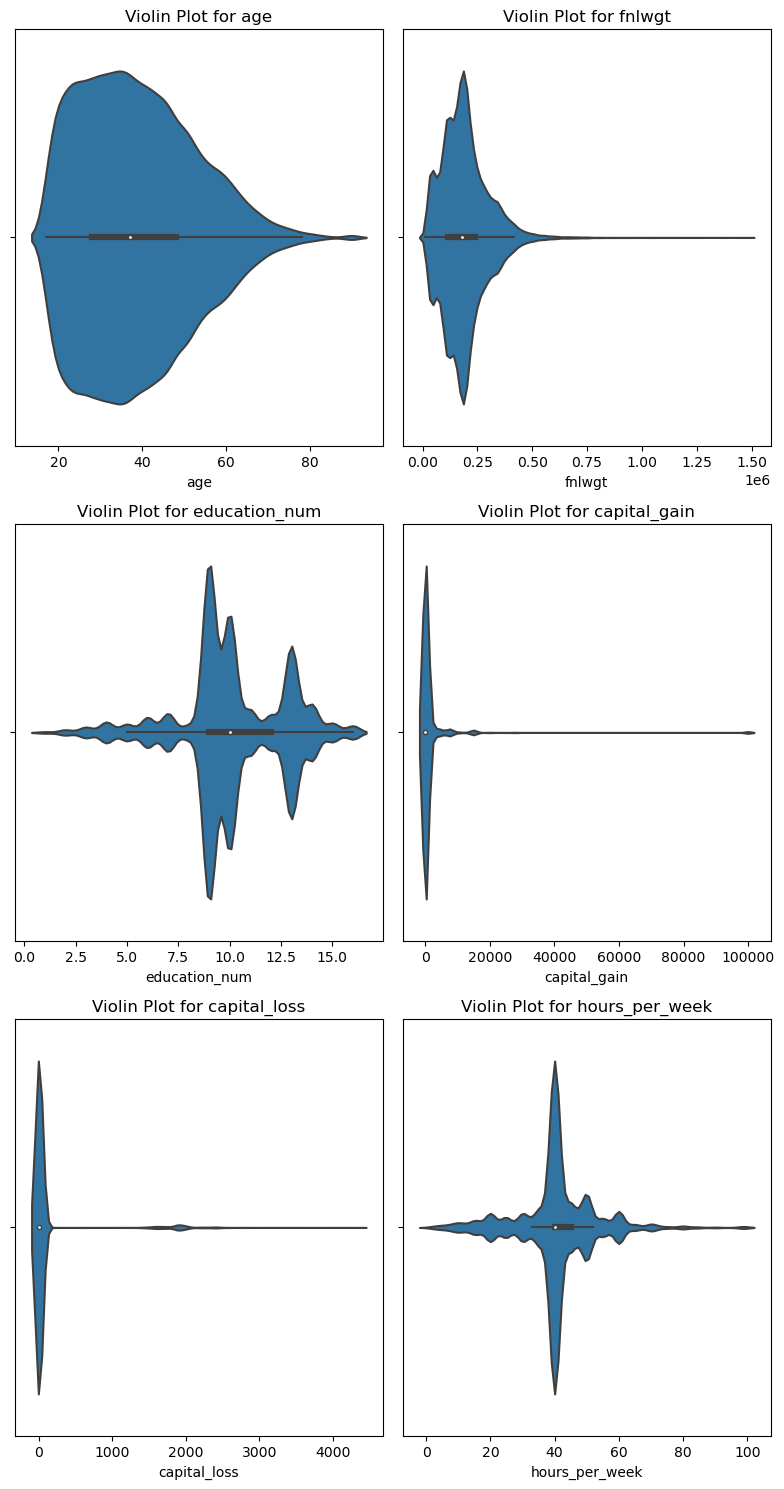

In [9]:
## Plot Numeric Columns

# Select numeric columns
numeric_columns = adult.select_dtypes(include=['int', 'float']).columns

# Set the number of columns and rows for the subplots grid
num_cols = 2
num_rows = (len(numeric_columns) + num_cols - 1) // num_cols

# Create the subplots grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 15))

# Flatten the axes array to iterate over the subplots
axes = axes.flatten()

# Draw violin plot for each numeric column
for i, column in enumerate(numeric_columns):
    sns.violinplot(x=adult[column], ax=axes[i])
    axes[i].set_title(f"Violin Plot for {column}")

# Remove any unused subplots
if len(numeric_columns) < len(axes):
    for j in range(len(numeric_columns), len(axes)):
        fig.delaxes(axes[j])

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
plt.show()


By what we see in the plots, I will use Robust Scaler for `capital_loss`, `capital_gain`, `fnlwgt` and use Standard Scaler for `education_num`, `age`, `hours_per_week`.

In [10]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# Feature scaling
columns_robust = ['capital_loss', 'capital_gain', 'fnlwgt']
columns_standard = ['education_num', 'age', 'hours_per_week']
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()
X_train_a[columns_robust] = robust_scaler.fit_transform(X_train_a[columns_robust])
X_train_a[columns_standard] = standard_scaler.fit_transform(X_train_a[columns_standard])



In [11]:
# Apply the same scaling transformations to the test set
X_test_a[columns_robust] = robust_scaler.transform(X_test_a[columns_robust])
X_test_a[columns_standard] = standard_scaler.transform(X_test_a[columns_standard])


In [14]:
# Select non-numeric columns
non_numeric_columns = adult.select_dtypes(exclude=['int', 'float']).columns

# Create a dictionary for each non-numeric column to store unique values and their counts
unique_values_counts = {}
for column in non_numeric_columns:
    unique_values_counts[column] = adult[column].value_counts().to_dict()

# Print the dictionaries
for column, value_counts in unique_values_counts.items():
    print(f"'{column}': {value_counts}")


'workclass': {' Private': 22696, ' Self-emp-not-inc': 2541, ' Local-gov': 2093, ' ?': 1836, ' State-gov': 1297, ' Self-emp-inc': 1116, ' Federal-gov': 960, ' Without-pay': 14, ' Never-worked': 7}
'education': {' HS-grad': 10501, ' Some-college': 7291, ' Bachelors': 5354, ' Masters': 1723, ' Assoc-voc': 1382, ' 11th': 1175, ' Assoc-acdm': 1067, ' 10th': 933, ' 7th-8th': 646, ' Prof-school': 576, ' 9th': 514, ' 12th': 433, ' Doctorate': 413, ' 5th-6th': 333, ' 1st-4th': 168, ' Preschool': 51}
'marital_status': {' Married-civ-spouse': 14976, ' Never-married': 10682, ' Divorced': 4443, ' Separated': 1025, ' Widowed': 993, ' Married-spouse-absent': 418, ' Married-AF-spouse': 23}
'occupation': {' Prof-specialty': 4140, ' Craft-repair': 4099, ' Exec-managerial': 4066, ' Adm-clerical': 3769, ' Sales': 3650, ' Other-service': 3295, ' Machine-op-inspct': 2002, ' ?': 1843, ' Transport-moving': 1597, ' Handlers-cleaners': 1370, ' Farming-fishing': 994, ' Tech-support': 928, ' Protective-serv': 649

In [20]:
## Handle Categorical VAriables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the columns that are non-numeric (categorical)
non_numeric_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

# Define the preprocessing steps for non-numeric columns using dense encoding
non_numeric_preprocessor = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse=False))
])

# Create a preprocessor that applies the appropriate preprocessing steps to each type of column
preprocessor = ColumnTransformer(transformers=[
    ('non_numeric', non_numeric_preprocessor, non_numeric_columns)
], remainder='passthrough')

# Create a pipeline that includes the preprocessing steps and the Naive Bayes classifier
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Train the pipeline
nb_pipeline.fit(X_train_a, y_train_a)

# Transform the training set
X_train_processed = nb_pipeline.named_steps['preprocessor'].transform(X_train_a)

# Transform the test set
X_test_processed = nb_pipeline.named_steps['preprocessor'].transform(X_test_a)




#### **Model training**

In [24]:
# Initialize Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier
nb_classifier.fit(X_train_processed, y_train_a)

GaussianNB()

In [25]:
# Make predictions
y_pred = nb_classifier.predict(X_test_processed)

#### **Check accuracy score and calulate f1-score, precision, recall**

In [28]:
# Calculate accuracy score
accuracy = accuracy_score(y_test_a, y_pred)

In [29]:
# Calculate f1-score, precision, and recall
f1 = f1_score(y_test_a, y_pred, average='weighted')
precision = precision_score(y_test_a, y_pred, average='weighted')
recall = recall_score(y_test_a, y_pred, average='weighted')

#### **Use ROC-AUC and also k-Fold Cross Validation**

#### **Calculate class possibilites**

In [44]:
# Calculate class probabilities
class_probabilities = nb_classifier.predict_proba(X_test_processed)

# Use k-Fold Cross Validation
cv_scores = cross_val_score(nb_classifier, X_test_processed, y_pred, cv=5)

In [43]:
import numpy as np

# Flatten the 2D array into a 1D array
y_test_flattened = np.ravel(y_test_a)

# Now you can use y_test_flattened to calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test_flattened, class_probabilities[:, 1])


In [45]:
# Print the results
print("Accuracy:", accuracy)
print("F1-score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)
print("Cross Validation Scores:", cv_scores)

Accuracy: 0.7968366093366094
F1-score: 0.8077715704318827
Precision: 0.8400671372636397
Recall: 0.7968366093366094
ROC-AUC: 0.8958934751628664
Cross Validation Scores: [0.93016117 0.93476592 0.91935484 0.92012289 0.90860215]


#### **Results and conclusion**
Briefly explain what you did and what you got

##### <font color="green">**Answer:**</font>

First I have plotted numeric variables and scaled it with the appropriate scalers. Then I handled non-numericals with dense one-hot encoder. After that I applied the same transformers on the test set.

Then I trained a nb calssifier model.

After that I have called the metrics.

The results shows that the model is performing well in predicting income levels based on the given features.

# KNN

## <font color="red">**Question 4**</font>


- Explain the k-Nearest Neighbors (k-NN) algorithm and its fundamental principle

### <font color="green">**Answer:**</font>

The fundamental principle behind k-NN is that similar things exist near each other.

In k-nn we assign labels based on similarity. Similiarity is measured by distance metrics. The distance metric used can be Euclidean distance, Manhattan distance, ... . \
To classify a new data point, we look at the k closest labeled data points and assign the most repeated label among those k neighbors to the new data point.

It is notable that k-nn algorithm doesn't solve any optimization problem so it doesn't need any presumption.

It is notable that the small amount of k may lead to overfitting means that the model will become too sensitive to noises and large values of k may lead to underfitting.

It is also notable that value of k should not be a multiple of the variable numbers because it may cause confusion in the algorithm.

## <font color="red">**Question 5**</font>
You're expected implement a K-Nearest Neighbors classifier. first import <font color="blue">**glass.csv**</font>. extract **Type column** as a target.

#### **Import libraries**

you can also import other libraries that you think is needed

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization
from sklearn.model_selection import train_test_split, GridSearchCV


#### **Import dataset**

In [ ]:
glass = pd.read_csv('glass.csv')


#### **Exploratory data analysis**

- **Data review (EDA, data cleaning, preprocess,...)**

In [ ]:
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
unique_counts = glass.nunique()
print(unique_counts)


RI      178
Na      142
Mg       94
Al      118
Si      133
K        65
Ca      143
Ba       34
Fe       32
Type      6
dtype: int64


In [ ]:
# Count non-numeric values
non_numeric_counts = glass.select_dtypes(exclude=[np.number]).apply(lambda x: x.notnull().sum())
print("Non-numeric value counts:")
print(non_numeric_counts)


Non-numeric value counts:
Series([], dtype: float64)


In [ ]:

# Count null values
null_counts = glass.isnull().sum()
print("Null value counts:")
print(null_counts)


Null value counts:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [ ]:
# Find duplicates
duplicates = glass[glass.duplicated()]
print("Duplicate rows:")
print(duplicates)


Duplicate rows:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
39  1.52213  14.21  3.82  0.47  71.77  0.11  9.57  0.0  0.0     1


In [ ]:
# Drop duplicates
glass.drop_duplicates(inplace=True)


#### **Data visualization**

- **Visualize the number of type in the dataset**
- **Use barplot, scatter plot,...**

In [ ]:
glass.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


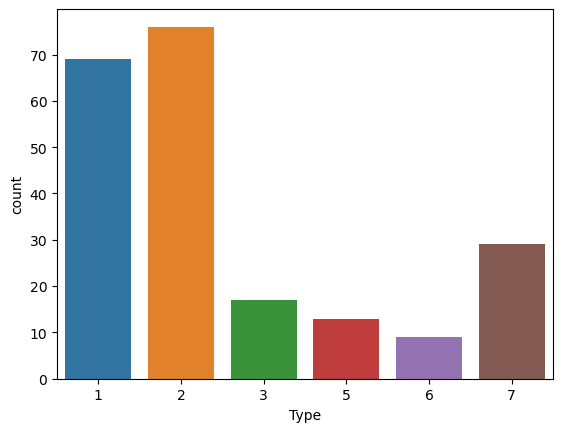

In [ ]:
# Visualize the number of type in the dataset
sns.countplot(x='Type', data=glass)
plt.show()


In [ ]:
# Separate the features (X) and the target variable (y)
X_glass = glass.drop('Type', axis=1)
y_glass = glass['Type']

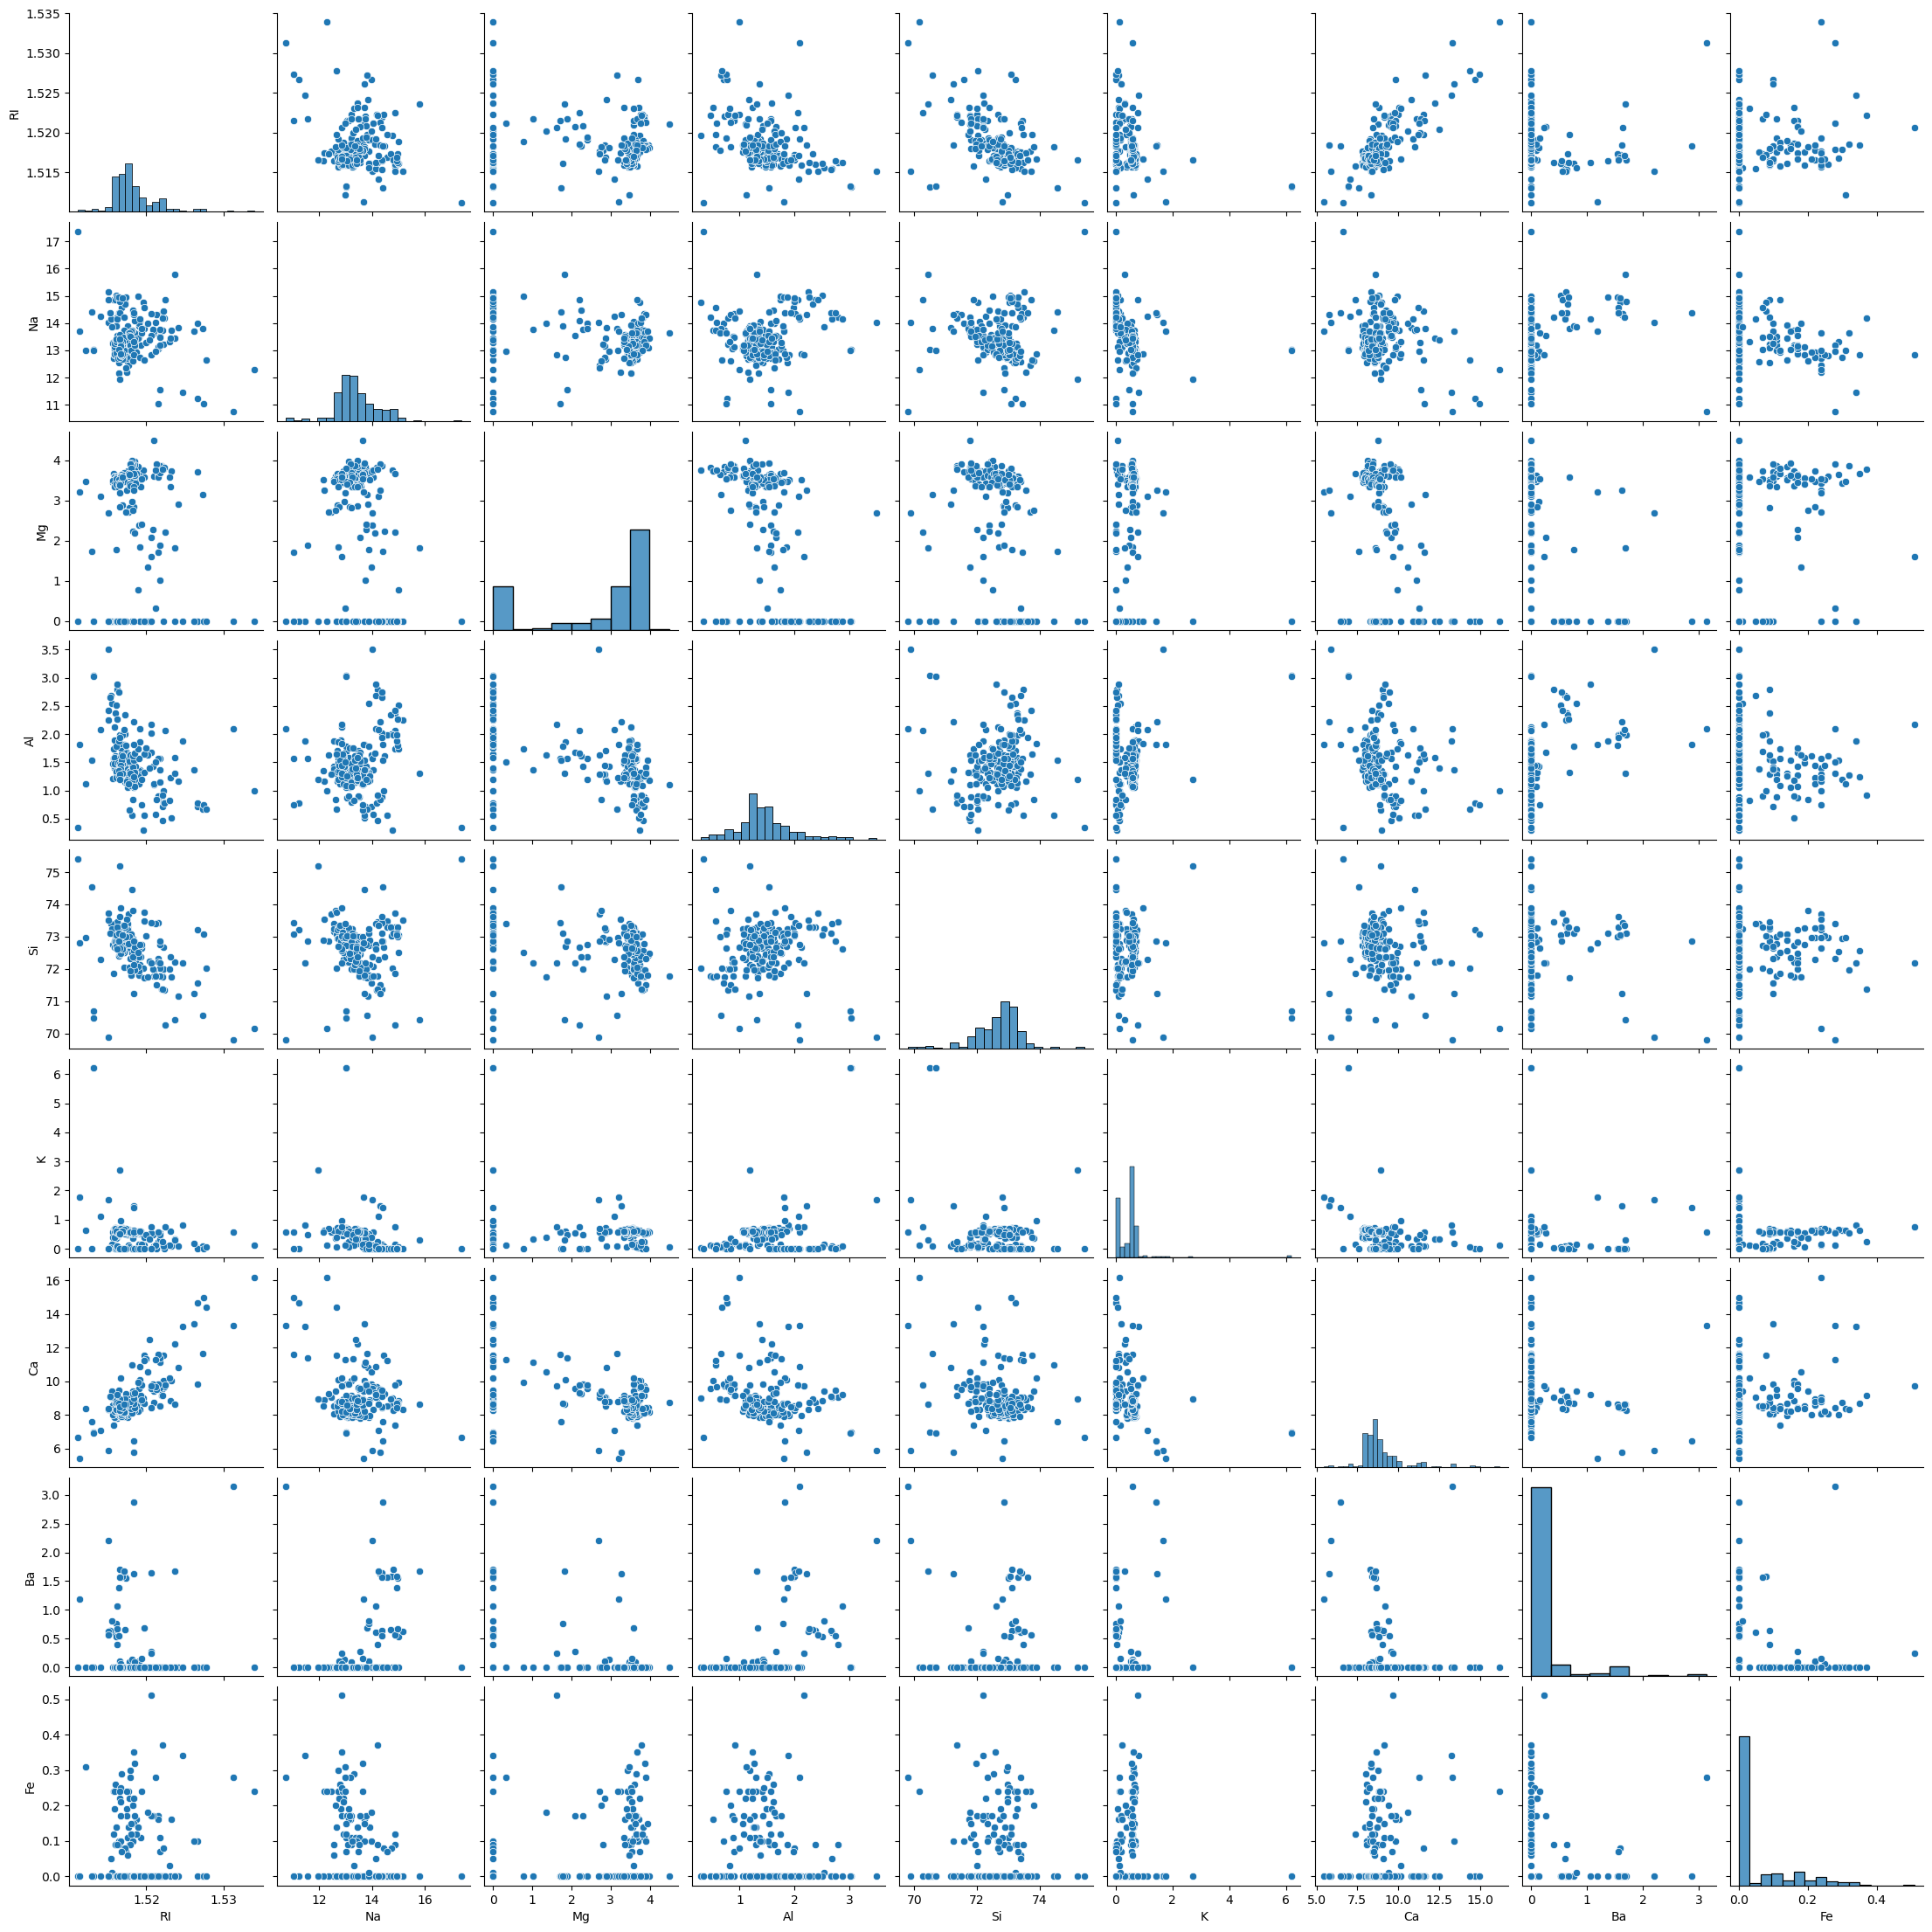

In [ ]:
# Draw pairplot
sns.pairplot(X_glass)
plt.show()


In [ ]:
X_glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


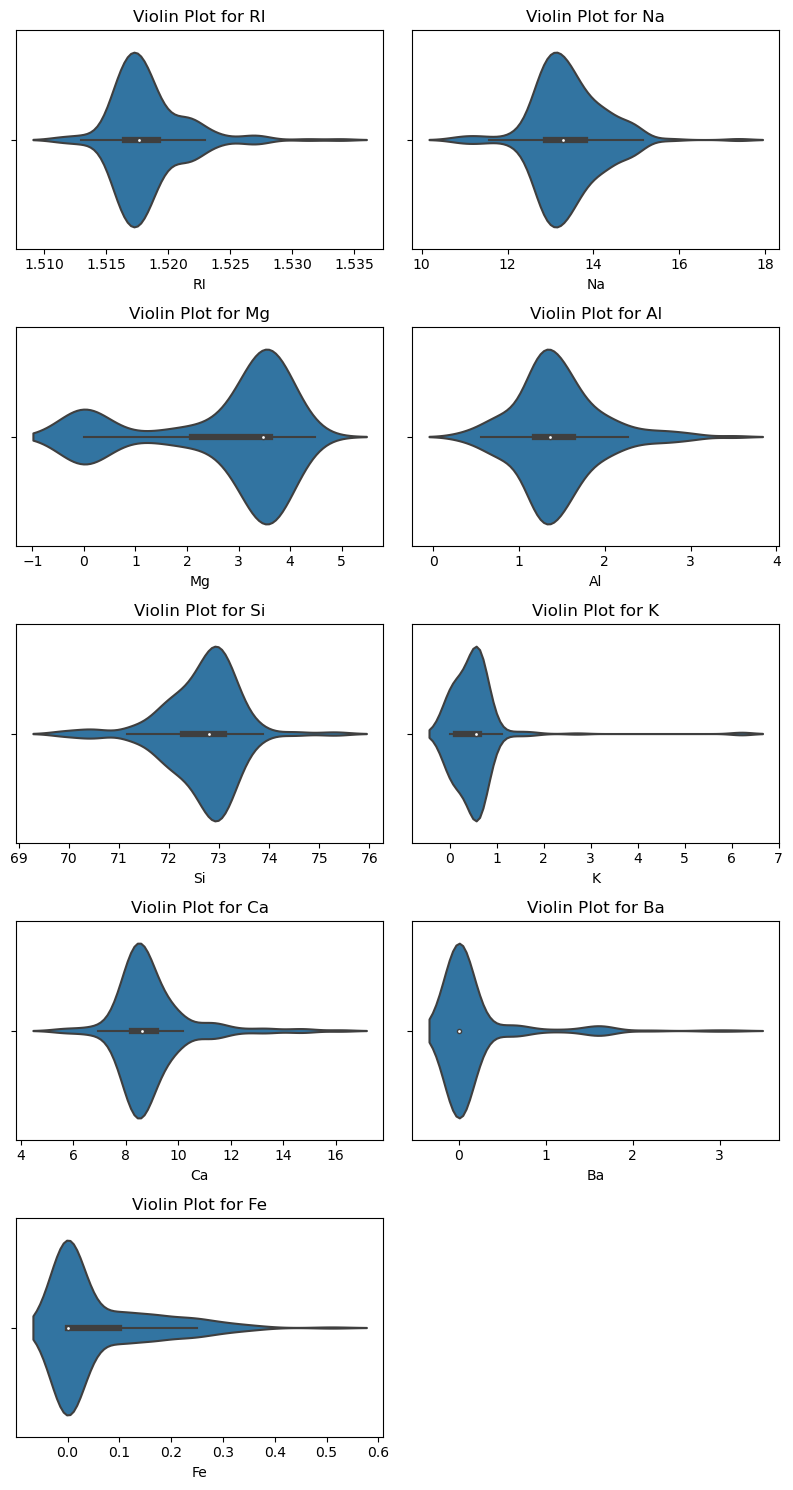

In [ ]:
# Set the number of columns and rows for the subplots grid
num_cols = 2
num_rows = (len(X_glass.columns) + num_cols - 1) // num_cols

# Create the subplots grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 15))

# Flatten the axes array to iterate over the subplots
axes = axes.flatten()

# Draw violin plot for each column
for i, column in enumerate(X_glass.columns):
    sns.violinplot(x=X_glass[column], ax=axes[i])
    axes[i].set_title(f"Violin Plot for {column}")

# Remove any unused subplots
if len(X_glass.columns) < len(axes):
    for j in range(len(X_glass.columns), len(axes)):
        fig.delaxes(axes[j])

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
plt.show()


#### **Data preparing for KNN**


Feature scaling is crucial for the KNN algorithm, as it helps in preventing features with larger magnitudes from dominating the distance calculations.

So I have decided to use a standard scaler for each column.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_glass, y_glass, test_size=0.2, random_state=42)

In [ ]:
# Apply feature scaling using StandardScaler
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)


#### **Training Model**


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Create a KNN classifier
knn = KNeighborsClassifier()

In [ ]:
# Train the KNN classifier
knn.fit(X_train_scaled, y_train)

# Evaluate the model on the testing set
accuracy = knn.score(X_test_scaled, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6976744186046512


#### **Find the best parameter of n_neighbors**
> <font color="orange">**Note:**</font>
**Use GridSearchCV**

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for GridSearchCV
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}

# Perform GridSearchCV to find the best parameter
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

# Get the best parameter and best score
best_param = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

# Create a table to store the results
results_table = pd.DataFrame(columns=['k-value', 'Best Score', 'Accuracy'])

# Iterate over the different k-values
for k in param_grid['n_neighbors']:
    # Train the KNN classifier with the current k-value
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Evaluate the model on the testing set
    accuracy = knn.score(X_test_scaled, y_test)
    
    # Append the results to the table
    results_table = results_table.append({'k-value': k, 'Best Score': best_score, 'Accuracy': accuracy}, ignore_index=True)

# Print the results table
print(results_table)


   k-value  Best Score  Accuracy
0      1.0    0.688235  0.720930
1      3.0    0.688235  0.697674
2      5.0    0.688235  0.697674
3      7.0    0.688235  0.697674
4      9.0    0.688235  0.604651
5     11.0    0.688235  0.627907


#### **Results and conclusion**
Briefly explain what you did and what you got

##### <font color="green">**Answer:**</font>

First I have plotted the data and fonud out that data doesn't need cleaning except a duplicated row which I have deleted it.

After that I decided to scale the data to avoid the impact of magnitude of some variables to dominant others.

Then I trained a model and fine-tuned it with Grid-Search.

The result shows that increasing K-value will decrease accuracy of the model. And the best K-value is one which ends up on 72% accuracy on the test set.

# Multi-class Classification
**Multi-class classification** is a type of supervised machine learning task where the goal is to assign a single input data point to one of multiple possible classes or categories.

## <font color="red">**Question 6**</font>

- What are two strategies of classify multi-class data? explain both and their differences.

$$\textbf{One-versus-the-Rest\;\; aka\;\; One-versus-All}$$

The first strategy is to train N binary classes, one for each class. In each class we will determine whether the objects are in the class or not.

For example if we want to distinguish 10 different races from each other, We will train 10 classes and in each class we will determine whether the object is in the class or not.

$$\textbf{One-versus-One}$$

On the other hand, in OvO strategy we will train a binary class to distinguish between every pair of classes. It will end up in $\frac{N \times N-1}{2}$ classifiers. The object will be classified in the class with most winning duels. While in this strategy you need to train more classifires but it is notable that you will train each classifier only needs to be trained on the part of the training set containing the two classes that it must distinguish.

This strategy is benfitable when we are using algorithms that are not good in scaling such as SVM.

### <font color="green">**Answer:**</font>

## <font color="red">**Question 7**</font>

So you are going to implement a multi-class classification. the one thing you should do is importing <font color="blue">**mobile price**</font> dataset. Target column is **price_range**.

> <font color="orange">**Note:**</font> Your code should be readable and with a lot ot explaination


#### **Import libraries**

you can also import other libraries that you think is needed

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization

#### **Import dataset**

In [ ]:
# Load the dataset
mobile_price_train = pd.read_csv('mobile price/train.csv')
mobile_price_predict = pd.read_csv('mobile price/test.csv')

# Target column "price_range"
train_target = pd.DataFrame(mobile_price_train['price_range'])



In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into train and test sets
mobile_price_train, mobile_price_test = train_test_split(mobile_price_train, test_size=0.2, random_state=42)


In [ ]:
mobile_price_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
968,1923,0,0.5,1,7,0,46,0.5,191,1,...,767,1759,1489,10,9,3,1,1,1,1
240,633,1,2.2,0,0,1,49,0.1,139,8,...,529,1009,3560,11,1,16,1,1,1,2
819,1236,0,0.9,1,2,1,57,0.1,188,1,...,517,809,1406,14,12,20,1,0,1,0
692,781,0,1.1,0,2,0,38,0.4,198,5,...,304,1674,3508,13,8,5,0,0,1,3
420,1456,1,0.5,1,7,0,7,0.4,105,5,...,823,1104,1587,6,5,20,1,0,1,1


In [ ]:
# Print the first few rows of the target column
print(train_target.head())

   price_range
0            1
1            2
2            2
3            2
4            1


In [ ]:
# Print the unique values and their frequencies
print(train_target.value_counts())

price_range
0              500
1              500
2              500
3              500
dtype: int64


#### **Exploratory data analysis**

- **If necessary EDA, data cleaning, preprocess...**

In [ ]:
# Print the column names
print(mobile_price_train.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [ ]:
# Find null values
null_values = mobile_price_train.isnull().sum()

# Print the null values
print(null_values)


battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [ ]:
# Create an empty dictionary to store the results
unique_type_counts = {}

# Iterate over the columns
for column in mobile_price_train.columns:
    # Get the unique types of values and their counts in the column
    unique_types = mobile_price_train[column].apply(type).unique()
    
    # Count the occurrences of each unique type
    type_counts = {str(t): sum(mobile_price_train[column].apply(type) == t) for t in unique_types}
    
    # Store the unique types and their counts in the dictionary
    unique_type_counts[column] = type_counts

# Print the dictionary
print(unique_type_counts)


{'battery_power': {"<class 'int'>": 1600}, 'blue': {"<class 'int'>": 1600}, 'clock_speed': {"<class 'float'>": 1600}, 'dual_sim': {"<class 'int'>": 1600}, 'fc': {"<class 'int'>": 1600}, 'four_g': {"<class 'int'>": 1600}, 'int_memory': {"<class 'int'>": 1600}, 'm_dep': {"<class 'float'>": 1600}, 'mobile_wt': {"<class 'int'>": 1600}, 'n_cores': {"<class 'int'>": 1600}, 'pc': {"<class 'int'>": 1600}, 'px_height': {"<class 'int'>": 1600}, 'px_width': {"<class 'int'>": 1600}, 'ram': {"<class 'int'>": 1600}, 'sc_h': {"<class 'int'>": 1600}, 'sc_w': {"<class 'int'>": 1600}, 'talk_time': {"<class 'int'>": 1600}, 'three_g': {"<class 'int'>": 1600}, 'touch_screen': {"<class 'int'>": 1600}, 'wifi': {"<class 'int'>": 1600}, 'price_range': {"<class 'int'>": 1600}}


#### **Data visualization**

- **corr, hist...**

There is no Null value in the datset and all values are numerical. Now lets check every column to find out whether there are any outliers or irrational data in there or not.

To find the outliers and bad data I will plot the data, first histogram to find type of the data, whether they are categorical, binary or continuous. Then I will plot the continuous ones to have some intuition of data.

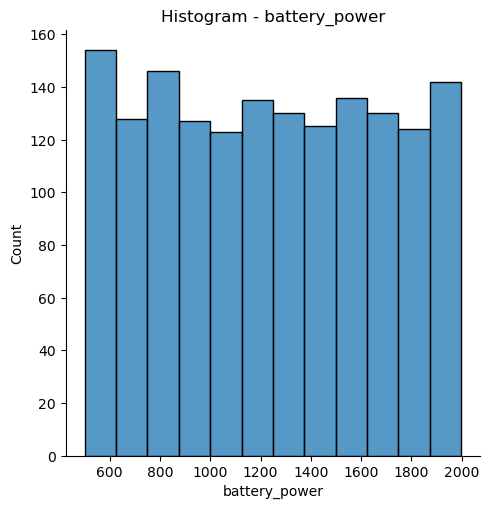

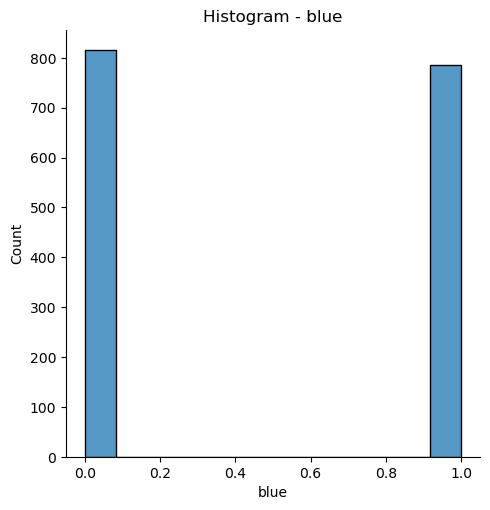

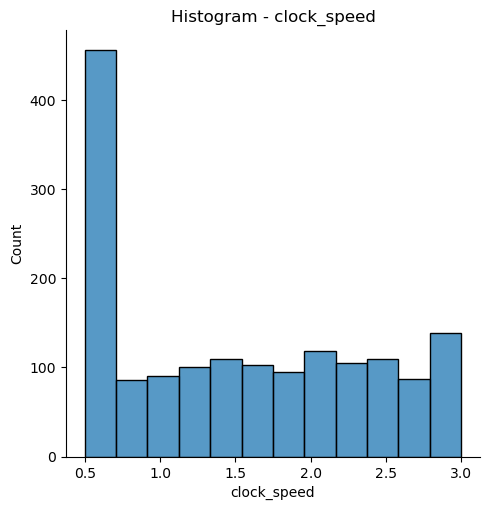

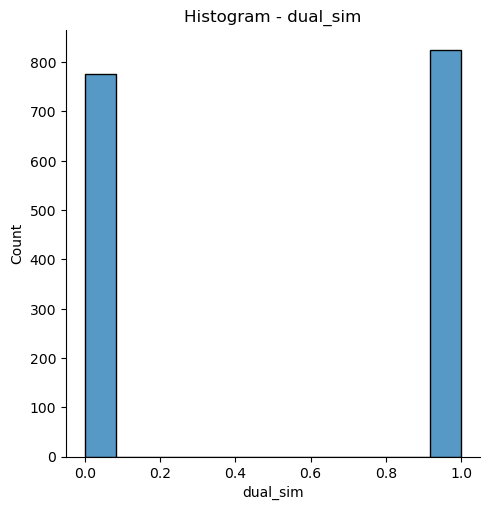

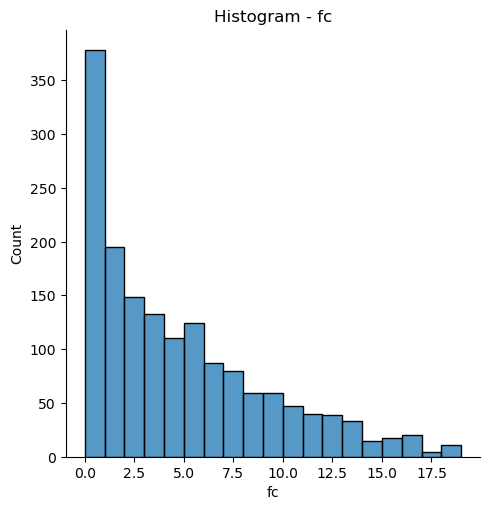

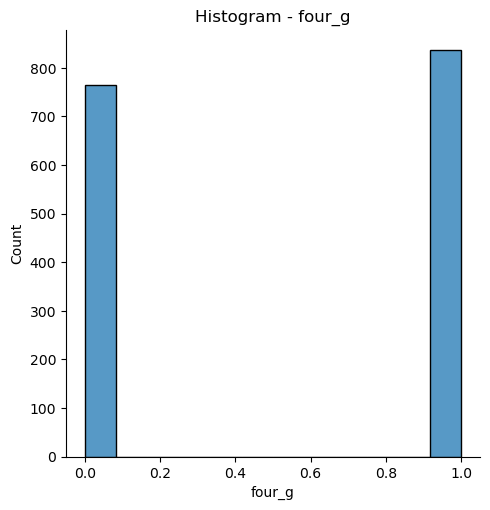

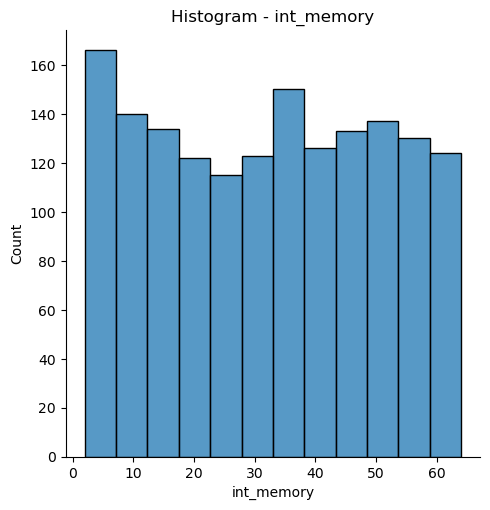

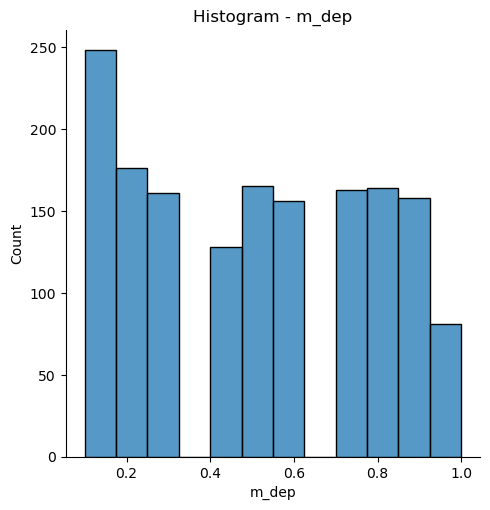

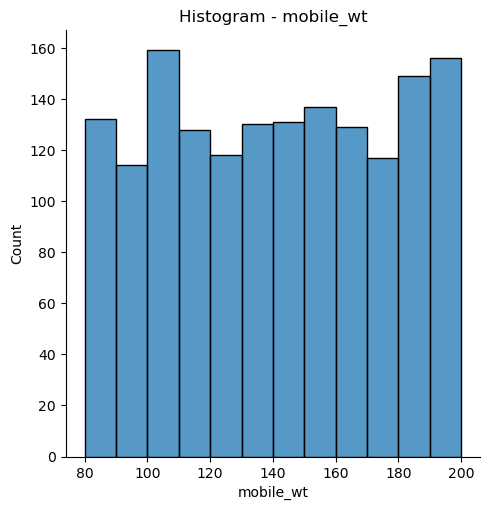

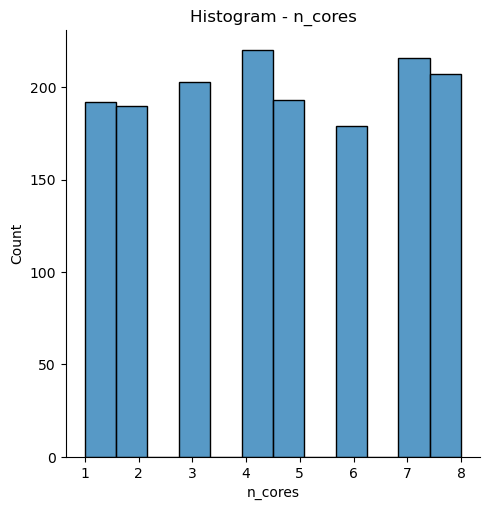

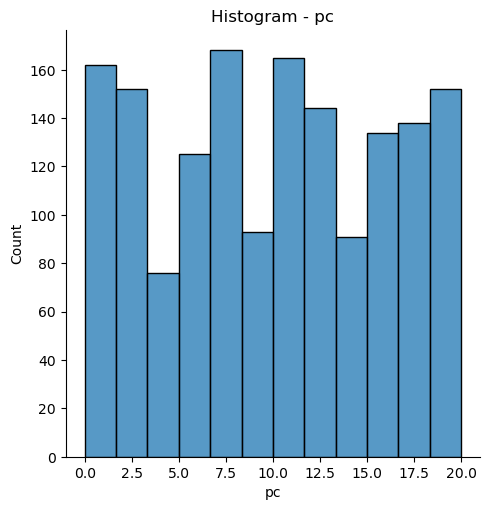

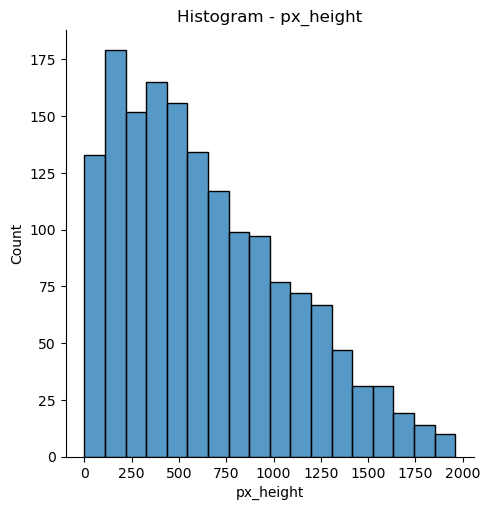

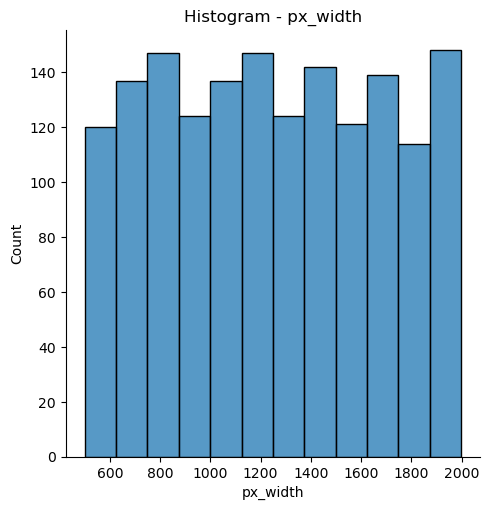

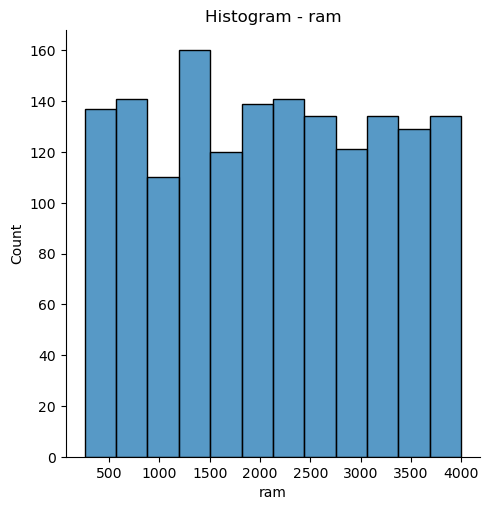

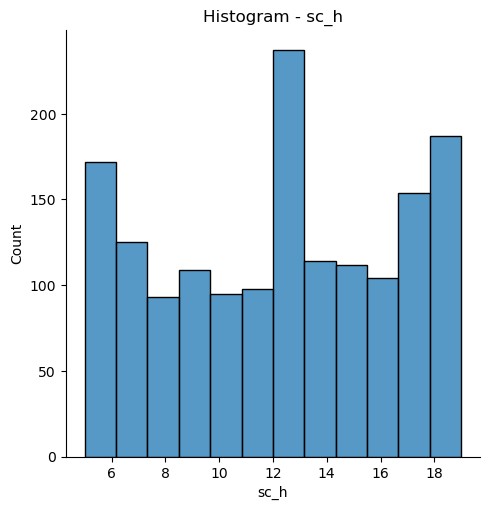

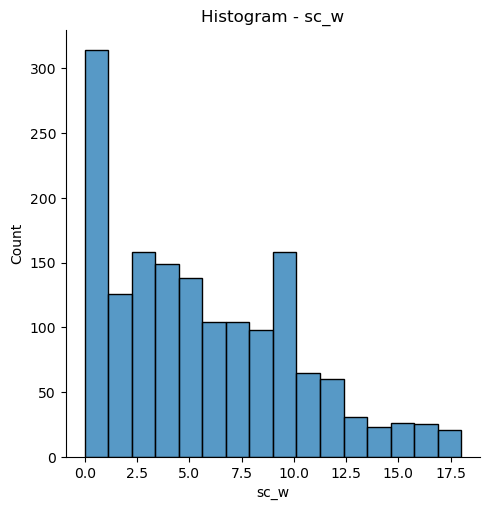

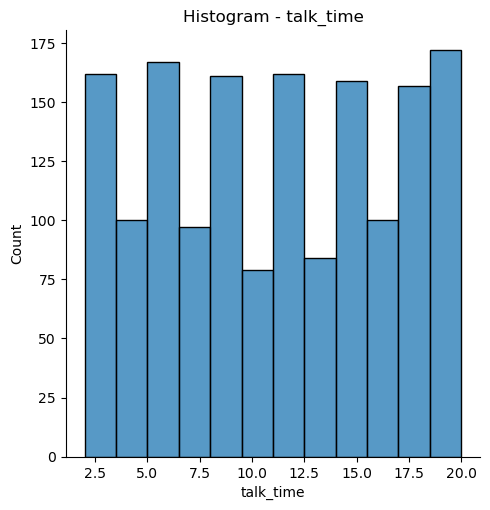

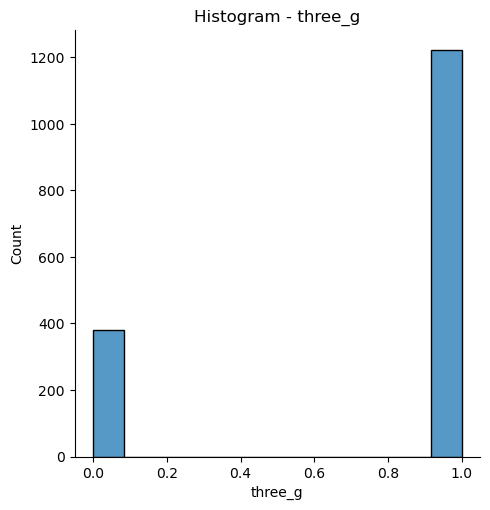

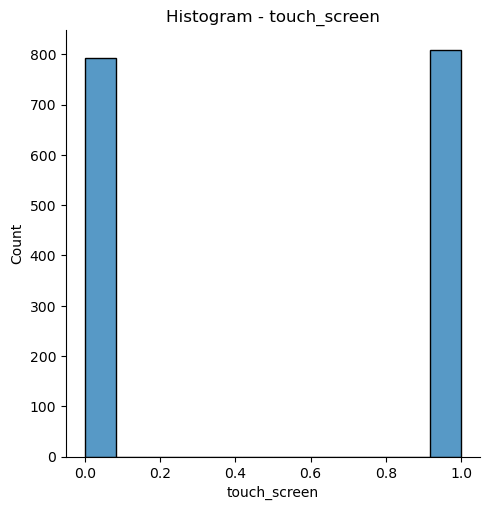

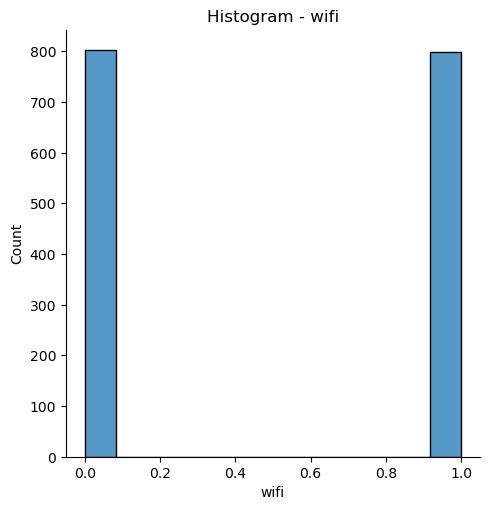

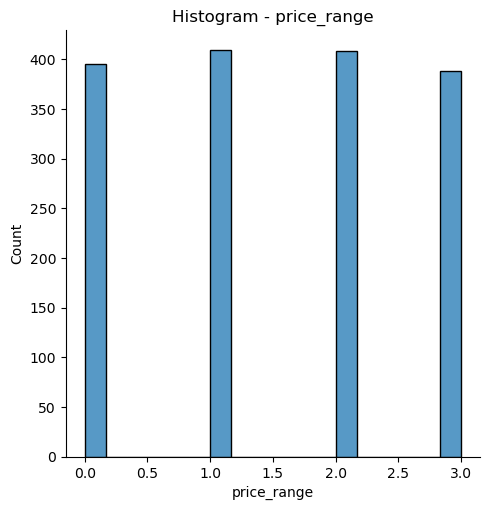

In [ ]:
# Iterate over the columns
for column in mobile_price_train.columns:
    # Create a histogram
    sns.displot(x=column, data=mobile_price_train, kde=False)
    
    # Set plot title
    plt.title(f"Histogram - {column}")
    

    # Show the plot
    plt.show()


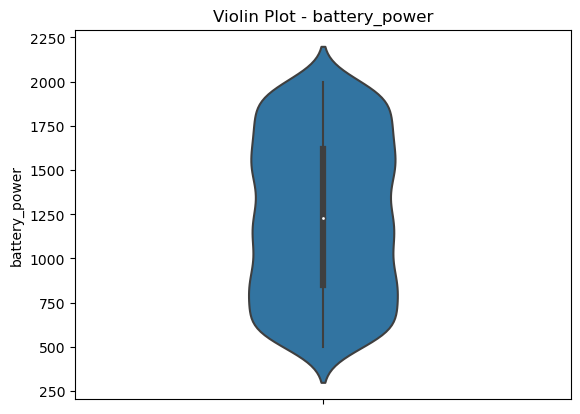

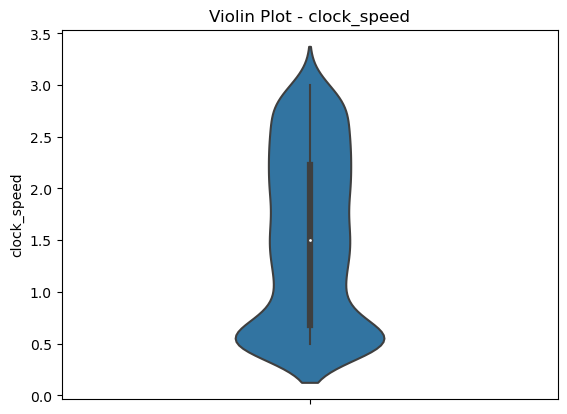

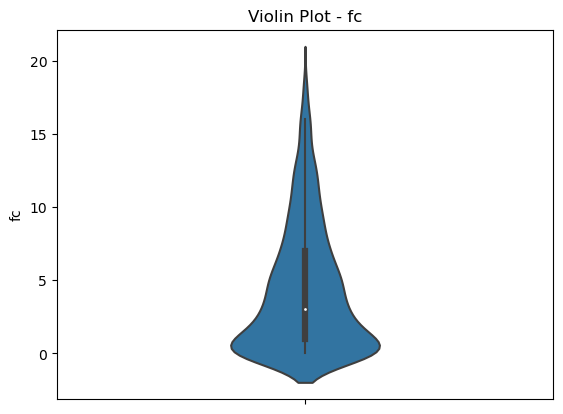

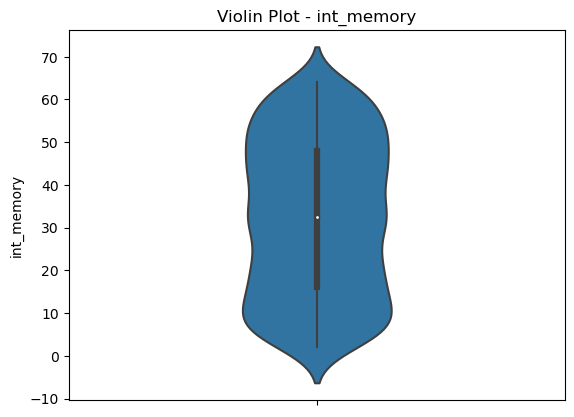

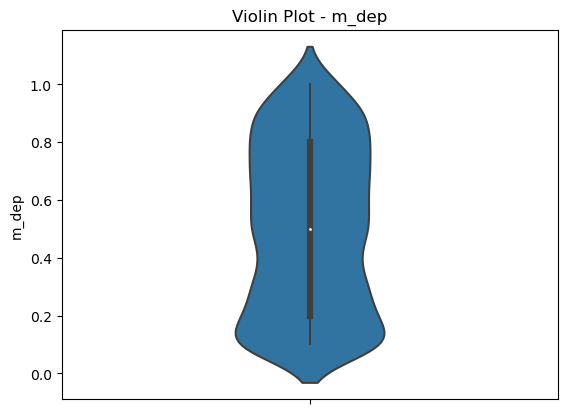

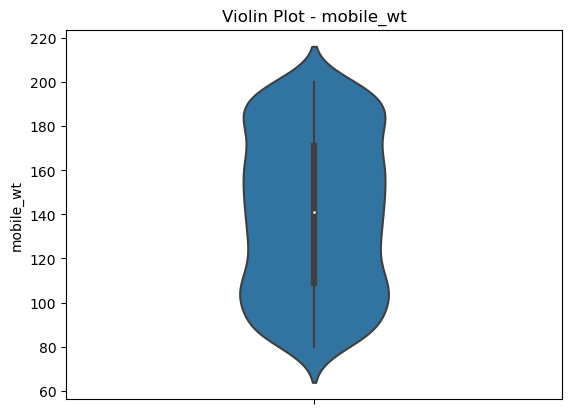

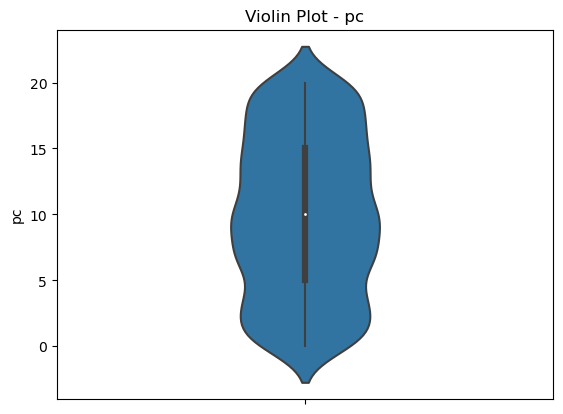

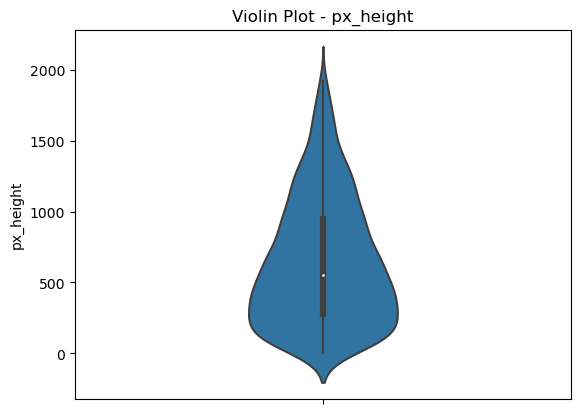

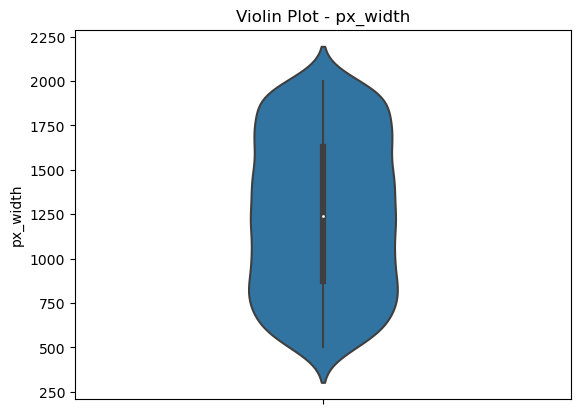

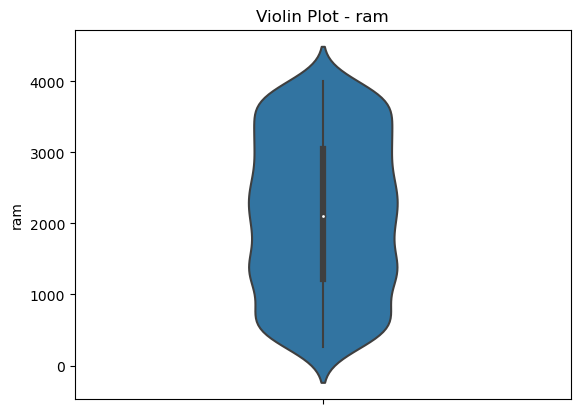

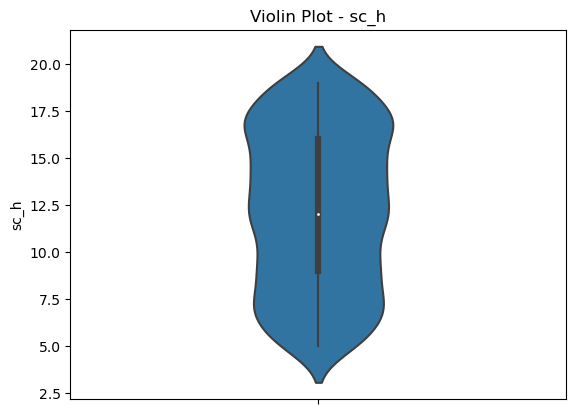

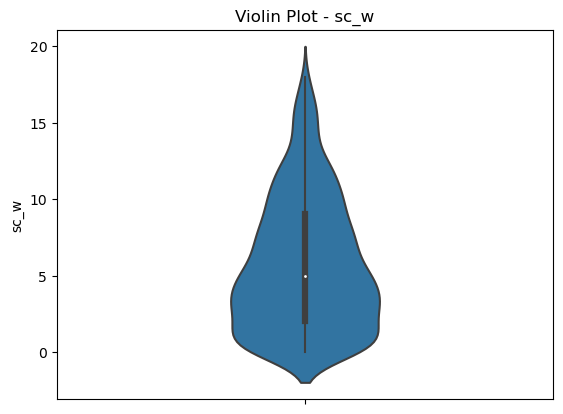

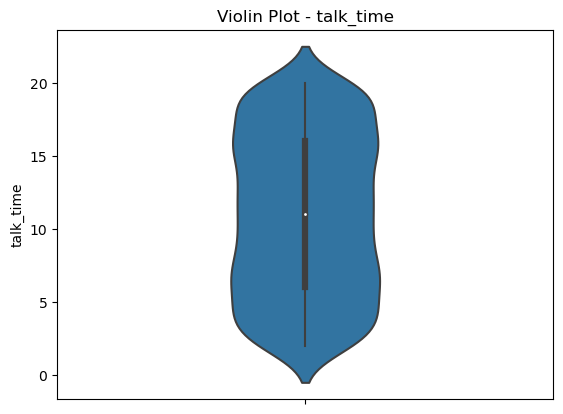

In [ ]:
# plot violin plots for continuous variables

# Columns to exclude from the plots
excluded_columns = ['price_range', 'wifi', 'touch_screen', 'three_g', 'four_g', 'dual_sim', 'blue', 'n_cores']

# Iterate over the columns
for column in mobile_price_train.columns:
    # Check if the column is in the excluded columns list
    if column in excluded_columns:
        continue
    
    # Create a violin plot
    sns.violinplot(y=column, data=mobile_price_train, width=0.3)
    
    # Set plot title
    plt.title(f"Violin Plot - {column}")

    
    # Show the plot
    plt.show()


In the following code, we will plot correaltion matrix and then we will see which variables has the most correlation with price range.

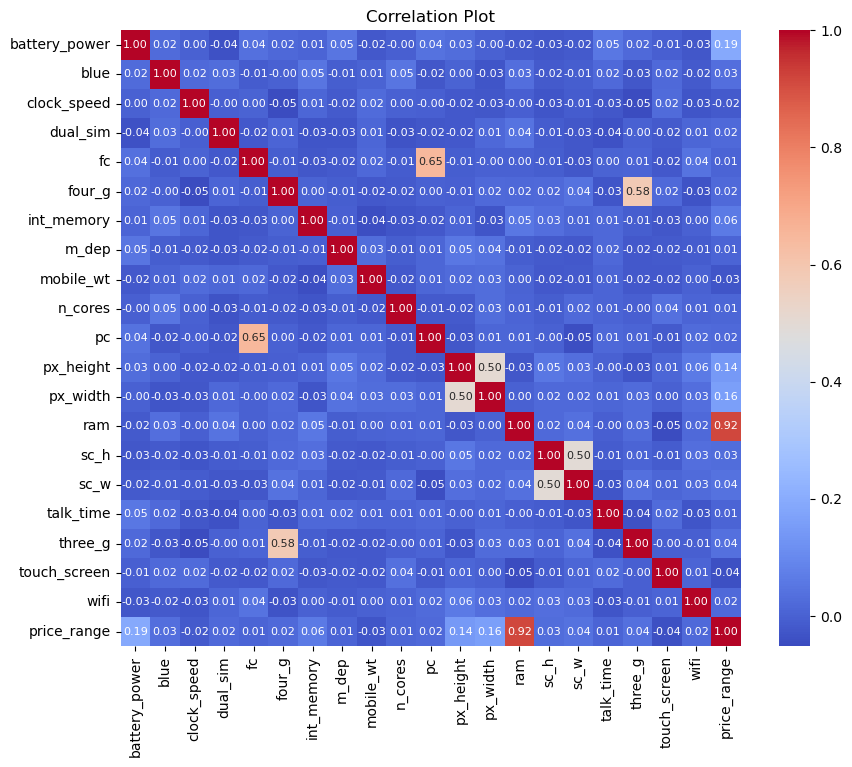

In [ ]:
# Calculate the correlation matrix
correlation_matrix = mobile_price_train.corr()

# Increase the figure size
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 8})

# Set plot title
plt.title("Correlation Plot")

# Show the plot
plt.show()

In [ ]:
# Sort correlation values with the 'price_range' column by absolute value
sorted_correlation = correlation_matrix['price_range'].abs().sort_values(ascending=False)

# Print the sorted correlation values
print(sorted_correlation)


price_range      1.000000
ram              0.915637
battery_power    0.194595
px_width         0.159829
px_height        0.144159
int_memory       0.061623
touch_screen     0.043356
sc_w             0.041111
three_g          0.035667
blue             0.033720
mobile_wt        0.027820
sc_h             0.027282
four_g           0.020034
dual_sim         0.019929
pc               0.018863
wifi             0.018591
clock_speed      0.017364
n_cores          0.012061
talk_time        0.008400
m_dep            0.006642
fc               0.006032
Name: price_range, dtype: float64


#### **Data preparing**


I will use Standard Scaler on the columns which their violinplots had skewness and I will use MinMax Scaler on the column which their violin plot had pretty clean distribution.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the columns to scale
columns_to_scale_standard = ['clock_speed', 'fc', 'm_dep', 'px_height', 'sc_w']

# Create a StandardScaler object
standard_scaler = StandardScaler()

# Scale the selected columns
mobile_price_train[columns_to_scale_standard] = standard_scaler.fit_transform(mobile_price_train[columns_to_scale_standard])




In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select the columns to scale
columns_to_scale_min_max = [col for col in mobile_price_train.columns 
                    if col not in ['clock_speed', 'fc', 'm_dep', 'px_height', 'sc_w', # previously scaled
                                   'price_range', 'wifi', 'touch_screen', 'three_g', 'four_g', 'dual_sim', 'blue', 'n_cores']] # categorical or binary, no need to scale

# Create a MinMaxScaler object
min_max_scaler = MinMaxScaler()

# Scale the selected columns
mobile_price_train[columns_to_scale_min_max] = min_max_scaler.fit_transform(mobile_price_train[columns_to_scale_min_max])


In [ ]:
mobile_price_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
968,0.949900,0,-1.236230,1,0.620111,0,0.709677,-0.008935,0.925000,1,...,0.275712,0.840454,0.329144,0.357143,0.759509,0.055556,1,1,1,1
240,0.088176,1,0.837112,0,-0.993561,1,0.758065,-1.403674,0.491667,8,...,-0.258762,0.339786,0.882888,0.428571,-1.084869,0.777778,1,1,1,2
819,0.490982,0,-0.748385,1,-0.532512,1,0.887097,-1.403674,0.900000,1,...,-0.285711,0.206275,0.306952,0.642857,1.451150,1.000000,1,0,1,0
692,0.187041,0,-0.504462,0,-0.532512,0,0.580645,-0.357620,0.983333,5,...,-0.764042,0.783712,0.868984,0.571429,0.528962,0.166667,0,0,1,3
420,0.637943,1,-1.236230,1,0.620111,0,0.080645,-0.357620,0.208333,5,...,0.401470,0.403204,0.355348,0.071429,-0.162680,1.000000,1,0,1,1


#### **Training Model**
Choose at least two common algorithms like:
- k-Nearest Neighbors.
- Decision Trees.
- Naive Bayes.
- Random Forest.

In [ ]:
mobile_price_test[columns_to_scale_min_max] = min_max_scaler.fit_transform(mobile_price_test[columns_to_scale_min_max])
mobile_price_test[columns_to_scale_standard] = standard_scaler.fit_transform(mobile_price_test[columns_to_scale_standard])

In [ ]:
mobile_price_test.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1860,0.767270,0,1.181832,0,-0.300571,1,0.370968,0.344717,1.000000,2,...,-1.001270,0.740147,0.115066,0.214286,-0.002830,0.500000,1,1,0,0
353,0.456070,0,-1.324040,0,0.618958,1,0.096774,0.005094,0.483333,8,...,-0.854843,0.324649,0.617340,1.000000,2.487392,0.944444,1,0,0,2
1333,0.985915,0,1.683006,0,1.078723,0,0.193548,-0.334528,0.966667,7,...,-0.813661,0.301937,0.283650,0.214286,-1.134749,0.333333,1,1,0,1
905,0.326626,1,0.555364,0,-0.070689,0,0.241935,-1.013772,0.716667,3,...,-0.898314,0.597194,0.972973,0.928571,0.223554,0.944444,1,1,0,3
1289,0.075788,1,-1.324040,1,0.618958,0,0.903226,0.005094,0.416667,5,...,0.851938,0.973948,0.441531,0.642857,-0.229214,0.166667,1,0,0,1


In [ ]:
mobile_price_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
968,0.949900,0,-1.236230,1,0.620111,0,0.709677,-0.008935,0.925000,1,...,0.275712,0.840454,0.329144,0.357143,0.759509,0.055556,1,1,1,1
240,0.088176,1,0.837112,0,-0.993561,1,0.758065,-1.403674,0.491667,8,...,-0.258762,0.339786,0.882888,0.428571,-1.084869,0.777778,1,1,1,2
819,0.490982,0,-0.748385,1,-0.532512,1,0.887097,-1.403674,0.900000,1,...,-0.285711,0.206275,0.306952,0.642857,1.451150,1.000000,1,0,1,0
692,0.187041,0,-0.504462,0,-0.532512,0,0.580645,-0.357620,0.983333,5,...,-0.764042,0.783712,0.868984,0.571429,0.528962,0.166667,0,0,1,3
420,0.637943,1,-1.236230,1,0.620111,0,0.080645,-0.357620,0.208333,5,...,0.401470,0.403204,0.355348,0.071429,-0.162680,1.000000,1,0,1,1


In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split the data into features (X) and target variable (y)
X_train = mobile_price_train.drop('price_range', axis=1)
y_train = mobile_price_train['price_range']
X_test = mobile_price_test.drop('price_range', axis=1)
y_test = mobile_price_test['price_range']

# Initialize the models
knn = KNeighborsClassifier()  # K-Nearest Neighbors classifier
dt = DecisionTreeClassifier()  # Decision Tree classifier
nb = GaussianNB()  # Naive Bayes classifier
rf = RandomForestClassifier()  # Random Forest classifier

# Train the models
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Make predictions on the test set
knn_pred = knn.predict(X_test)
dt_pred = dt.predict(X_test)
nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)

# Calculate accuracy scores
knn_accuracy = accuracy_score(y_test, knn_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Print the accuracy scores
print("K-Nearest Neighbors Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)
print("Random Forest Accuracy:", rf_accuracy)


K-Nearest Neighbors Accuracy: 0.3725
Decision Tree Accuracy: 0.825
Naive Bayes Accuracy: 0.8
Random Forest Accuracy: 0.89


#### **Show and analyze confusion matrix, recall, accuracy, precision and other metrics that you think is useful**

Now we will analyze the results for the top 2 models which are Desicion Tree and Random Forest.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Calculate and print classification report

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       105
           1       0.73      0.82      0.77        91
           2       0.76      0.72      0.74        92
           3       0.88      0.89      0.88       112

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.82      0.83       400

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       105
           1       0.86      0.87      0.86        91
           2       0.79      0.84      0.81        92
           3       0.93      0.89      0.91       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



In [ ]:
# Calculate and print confusion matrix

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Decision Tree Confusion Matrix:
[[ 89  16   0   0]
 [  7  75   9   0]
 [  0  12  66  14]
 [  0   0  12 100]]
Random Forest Confusion Matrix:
[[100   5   0   0]
 [  4  79   8   0]
 [  0   8  77   7]
 [  0   0  12 100]]


In [ ]:
# Retrieve feature importances from the Random Forest classifier
dt_feature_importances = dt.feature_importances_

# Create a DataFrame to store the feature importances
feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': dt_feature_importances})

# Sort the feature importances in descending order
sorted_feature_importances = feature_importances_df.sort_values(by='Importance', ascending=False)

# Print the sorted feature importances
print(sorted_feature_importances)


          Feature  Importance
13            ram    0.628965
0   battery_power    0.131652
11      px_height    0.082115
12       px_width    0.066283
8       mobile_wt    0.019771
9         n_cores    0.011215
10             pc    0.010243
2     clock_speed    0.009678
7           m_dep    0.009525
4              fc    0.006799
6      int_memory    0.005671
16      talk_time    0.005497
14           sc_h    0.005374
15           sc_w    0.004432
19           wifi    0.001111
5          four_g    0.000833
3        dual_sim    0.000833
1            blue    0.000000
17        three_g    0.000000
18   touch_screen    0.000000


In [ ]:
# Retrieve feature importances from the Random Forest classifier
rf_feature_importances = rf.feature_importances_

# Create a DataFrame to store the feature importances
feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_feature_importances})

# Sort the feature importances in descending order
sorted_feature_importances = feature_importances_df.sort_values(by='Importance', ascending=False)

# Print the sorted feature importances
print(sorted_feature_importances)


          Feature  Importance
13            ram    0.495149
0   battery_power    0.073009
12       px_width    0.055803
11      px_height    0.055264
8       mobile_wt    0.039478
6      int_memory    0.035223
16      talk_time    0.028948
10             pc    0.028217
14           sc_h    0.027953
15           sc_w    0.027081
2     clock_speed    0.026784
7           m_dep    0.024047
4              fc    0.023264
9         n_cores    0.021769
3        dual_sim    0.006863
19           wifi    0.006778
5          four_g    0.006528
18   touch_screen    0.006226
1            blue    0.005980
17        three_g    0.005636


As we expected from correlation matrix, `ram` is the most signifiacnt variable. The coefficient shows that `Random Forest` takes less important data more serious while `Desicion Tree` has neglected some variables. That maybe is the reason behind higher accuaracy of RF.

#### **Results and conclusion**
##### <font color="green">**Answer:**</font>


Since the test set hadn't included `price_range` column, I have splitted the train set into train and test.

Then I checked whether the data need cleaning or not, by count non-numeric an null variables, which ended up that data is clean.

After that I have plotted the data to find out whether we need tranformers or not, So I scaled continuous data.

After training model and before testing it, I also applied the same transformations on the test set.

After that I have tested 4 models and it ended up that DT and RF are better models for this data, so I analyzed the results for this two models.

It is notable that KNN accuaracy is significantly lower than other models, it is maybe because of high-dimensionality of data and because there are many unrelated variables in data which may lead to poor performance of this model.

The result analyze is:

$$\textbf{Decision Tree Classifier}:$$
- Precision: The precision values for class 0, 1, 2, and 3 are 0.94, 0.73, 0.78, and 0.88, respectively. This indicates that the classifier performs well in predicting class 0 and 3, but relatively worse for class 1 and 2.
- Recall: The recall values for class 0, 1, 2, and 3 are 0.83, 0.85, 0.73, and 0.90, respectively. This means that the classifier is good at identifying class 0, 1, and 3, but struggles with class 2.
- F1-score: The F1-scores for class 0, 1, 2, and 3 are 0.88, 0.78, 0.75, and 0.89, respectively. The F1-score provides a balanced measure of the classifier's performance, taking into account both precision and recall. Overall, the F1-scores are relatively high for all classes, indicating a good balance between precision and recall.
- Confusion Matrix: The confusion matrix shows the number of true positives, true negatives, false positives, and false negatives for each class. From the confusion matrix, we can observe that the classifier faces some difficulty in distinguishing between classes 1 and 2, as well as classes 2 and 3.



$$\textbf{Random Forest Classifier:}$$
- Precision: The precision values for class 0, 1, 2, and 3 are 0.93, 0.86, 0.79, and 0.93, respectively. This shows that the classifier performs well in predicting all classes, with high precision values for each class.
- Recall: The recall values for class 0, 1, 2, and 3 are 0.95, 0.85, 0.84, and 0.88. This means that the classifier is good at identifying all classes, although the recall is a little lower for class 1.
- F1-score: The F1-scores for class 0, 1, 2, and 3 are 0.94, 0.85, 0.81, and 0.91. The F1-scores are pretty high for all classes, which shows a good balance between precision and recall.
- Confusion Matrix: The confusion matrix shows that the classifier performs well in correctly classifying most instances for all classes, Since there are low numbers of false positives and false negatives.



In summary, both the `Decision Tree` and `Random Forest` classifiers demonstrate good performance with high accuracy scores. The Random Forest classifier is better than Decision Tree classifier in terms of precision, recall, and F1-score for most classes. However, the Decision Tree classifier has a higher recall for class 3.

# LDA and QDA

## Linear Discriminant Analysis (LDA)
Linear Discriminant Analysis is a supervised machine learning algorithm used for dimensionality reduction and classification. Its primary goal is to find a linear combination of features that best separates two or more classes in the data. LDA is particularly useful when you have labeled data and want to reduce the dimensionality while preserving class separability.

## Quadratic Discriminant Analysis (QDA)
Quadratic Discriminant Analysis is another supervised classification and dimensionality reduction technique used for similar purposes as LDA. However, it differs from LDA in a few key ways.

### <font color="red">**Question 7**</font>

#### <font color="green">**Answer:**</font>

- Contrast the key differences between Linear Discriminant Analysis (LDA) and Quadratic Discriminant Analysis (QDA). How do these differences impact the decision boundaries and flexibility of the two algorithms?
    
    * $\textbf{Covariance Matrix:}$\
    In QDA it is possible for different classes to have different covariance matrices, while LDA is a special case of QDA with an extra assumption of identical covariance matrices for all classes.
    
    * $\textbf{Decision boundary:}$\
    From the last assumption, QDA provides us a quadratic decision boundary while LDA provides a linear decision boundary. Which inidicates that QDA can capture more complexity in data.
    
    

- If the Bayes decision boundary is linear, do we expect LDA or QDA to perform better on the training set? On the test set?

    * If the Bayes decision boundary is linear, LDA will probably perform better on both training set and test set. The reason is that LDA has linear decision boundary assumption, which in this situation is a true assumption.\
    On the other hand QDA, may overfit the training data which may lead to poor performance on the test set.



- If the Bayes decision boundary is non-linear, do we expect LDA or QDA to perform better on the training set? On the test set?

    * If the Bayes decision boundary is non-linear, QDA will probably perform better on both training set and test set. The reason is that LDA has non-linear decision boundary assumption, which in this situation is a true assumption and could catch the complexity of the data.\
    On the other hand LDA, may underfit the training data and can't catch the complexity which may lead to poor performance on the test set.

### <font color="red">**Question 8**</font>

This question should be answered using the <font color="blue">**Weekly**</font> data set

#### **Import libraries**

you can also import other libraries that you think is needed

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization

#### **Import dataset**

In [ ]:
from ISLP import load_data
weekly = load_data('Weekly')

#### **a) Produce some numerical and graphical summaries of the Weekly data**

In [ ]:
# Summary statistics
weekly_summary = weekly.describe()
print(weekly_summary)


              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     1.409000   
max    2010.000000    12.026000    12.026000    12.026000    12.026000   

              Lag5       Volume        Today  
count  1089.000000  1089.000000  1089.000000  
mean      0.139893     1.574618     0.149899  
std       2.361285     1.686636     2.356927  
min     -18.195000     0.087465   -18.195000  
25%      -1.166000     0.332022    -1.154000  
50%       0.234000     1.002680     0.241000  
75% 

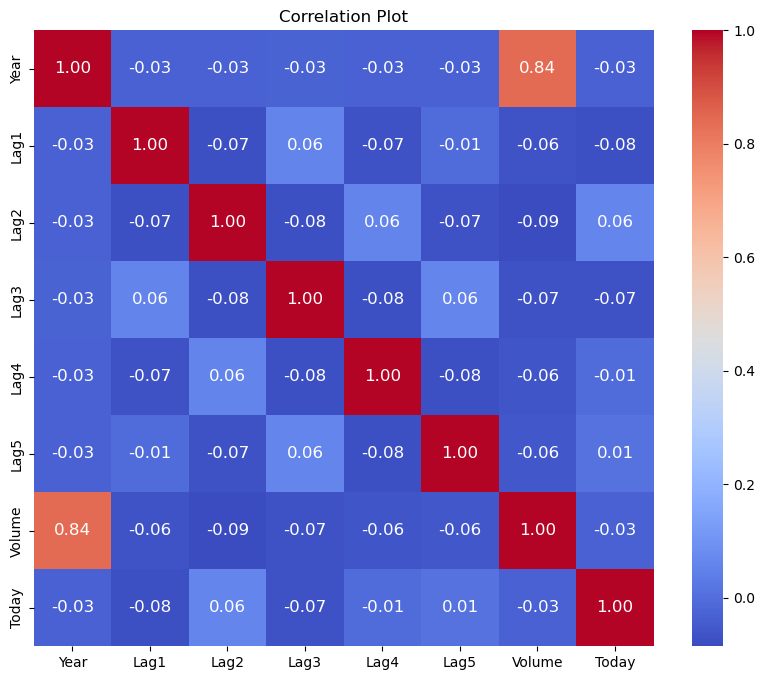

In [ ]:
# Calculate the correlation matrix
correlation_matrix = weekly.corr()

# Increase the figure size
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 12})

# Set plot title
plt.title("Correlation Plot")

# Show the plot
plt.show()

The correlation matrix shows a significant relation between Volume and Year, wwhile the lags are not really as important as the year.

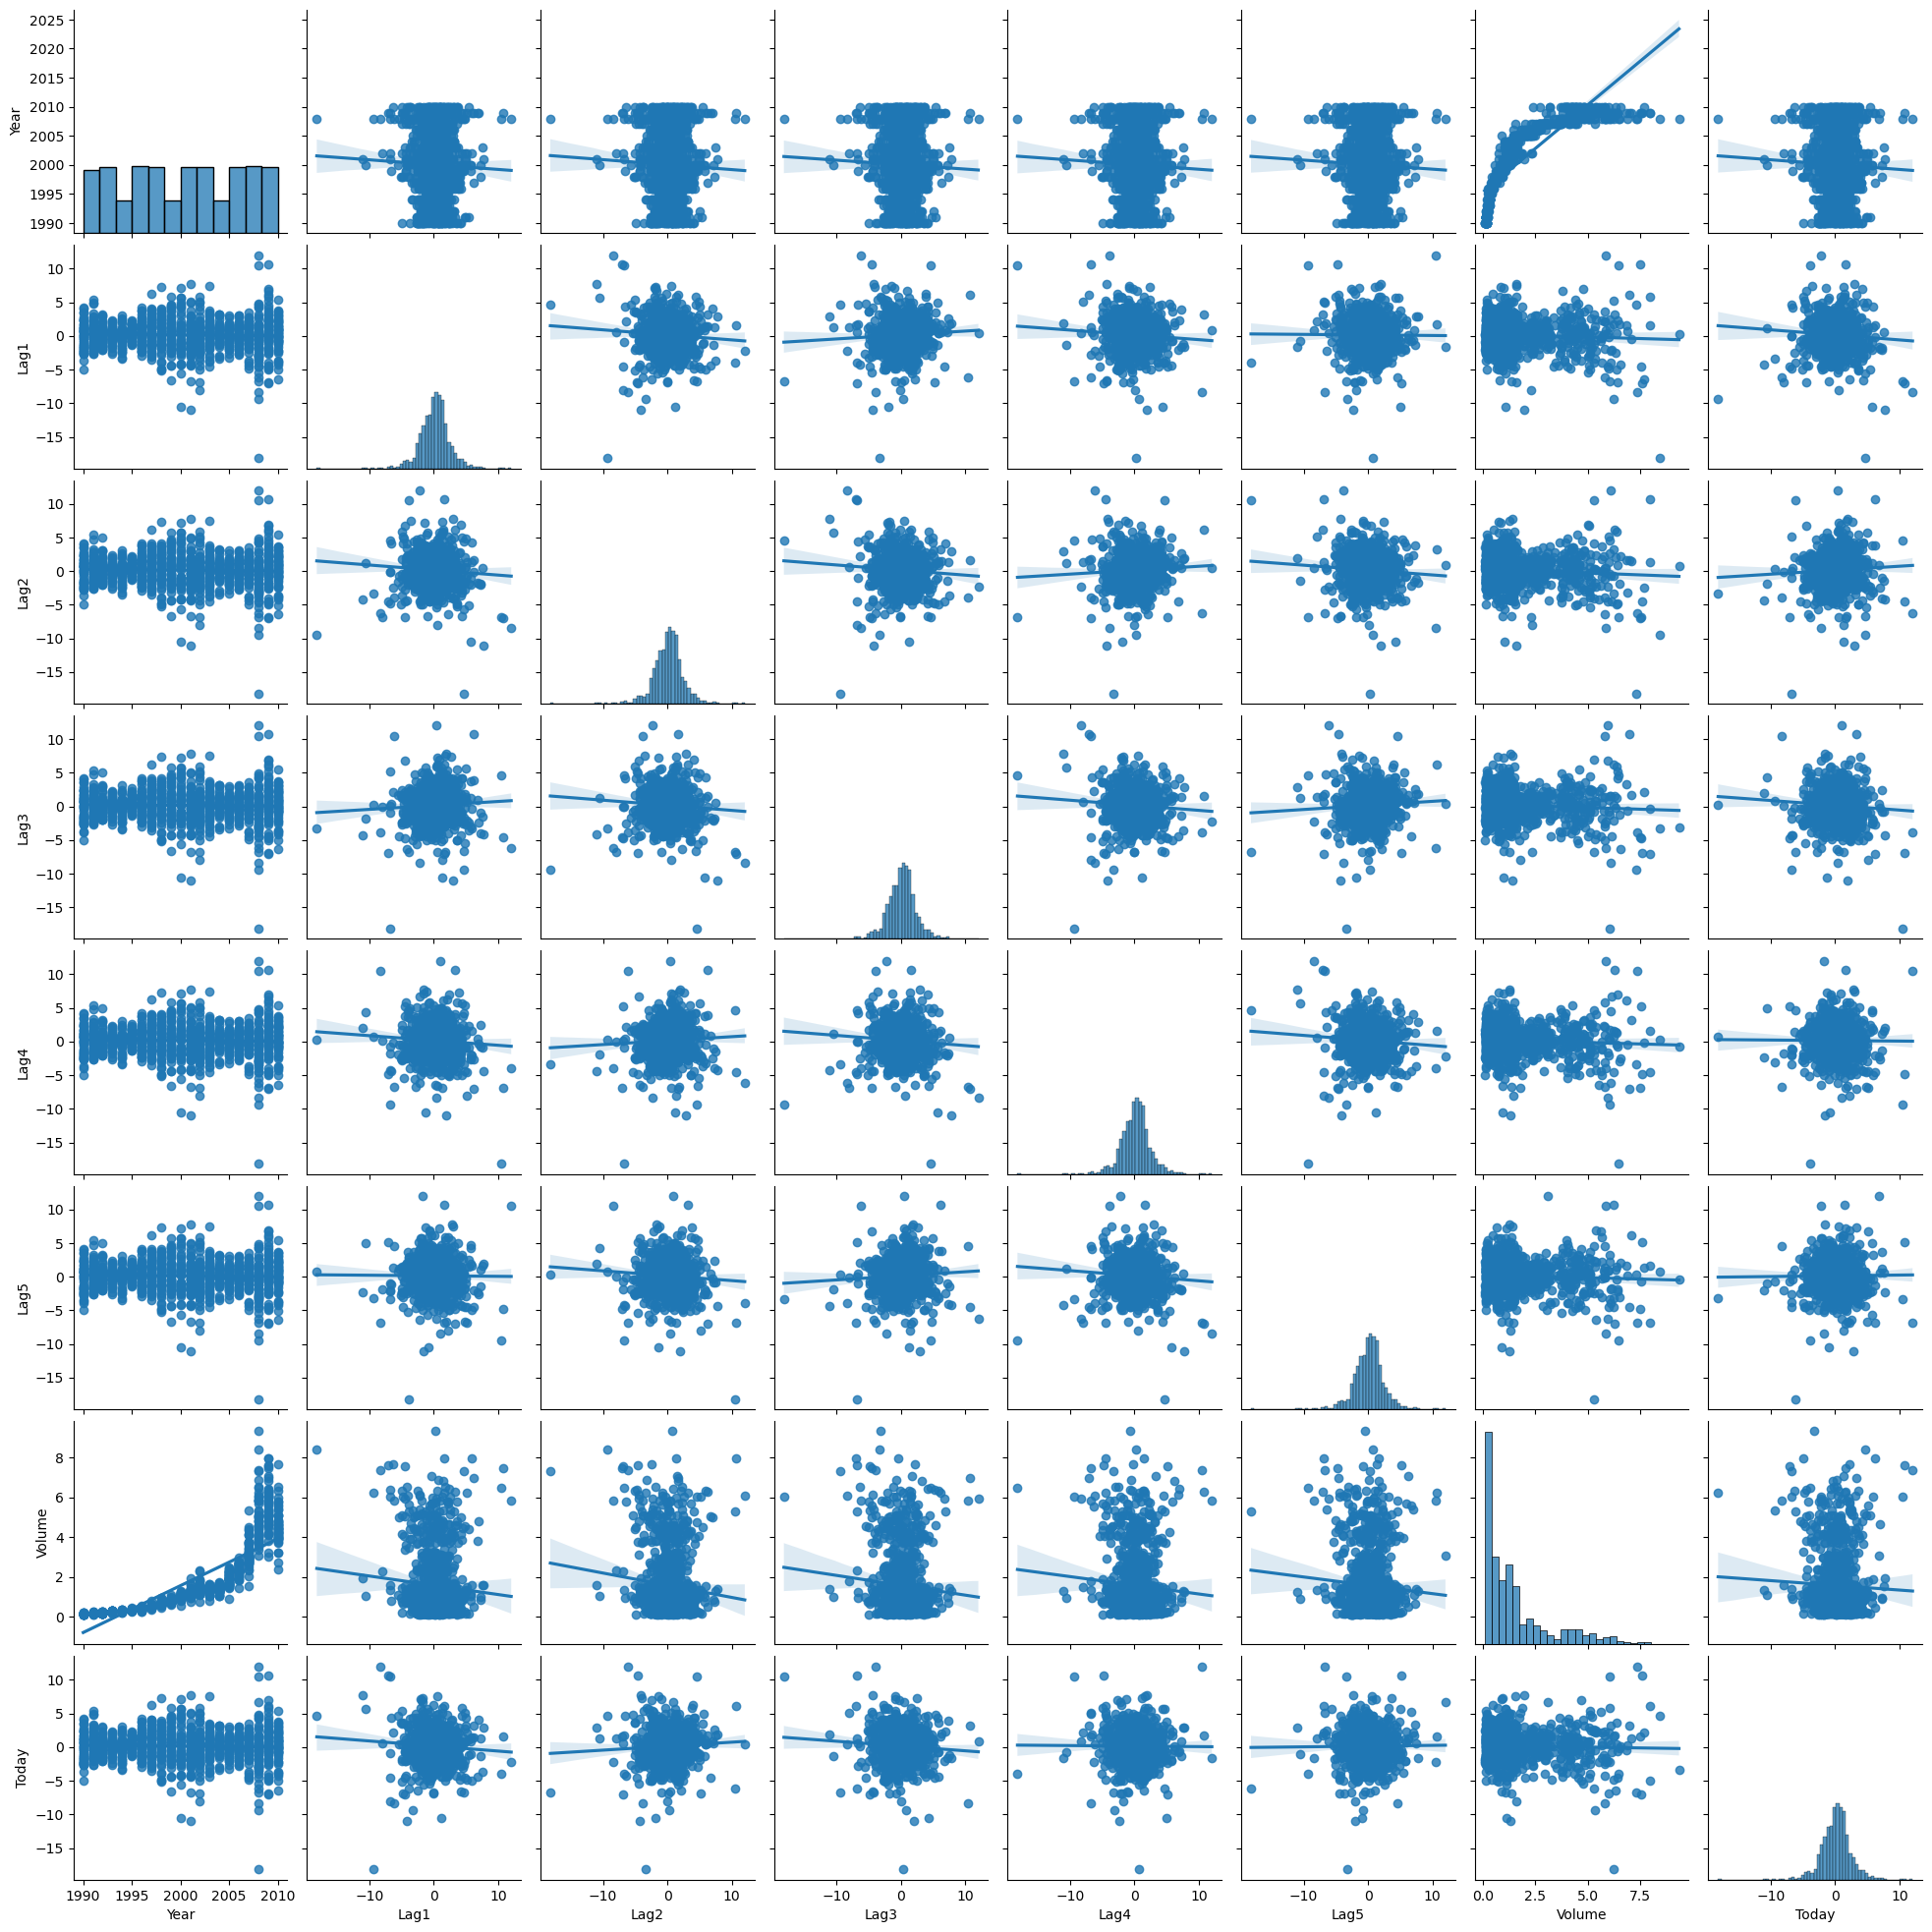

In [ ]:
# Pairplot
sns.pairplot(weekly, kind='reg')
plt.show()


- Do there appear to be any patterns?

    * Volume and year have significant realtionship.
    * Relationship of different lags is not really significant. It would have been better to identify relation if we had some circular measure instead of linear regression.

#### **b) Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results**

In [ ]:
# Sum of null values in each column
null_sum = weekly.isnull().sum()
print("Sum of null values in each column:")
print(null_sum)

# Sum of non-numeric data in each column
non_numeric_sum = weekly.apply(lambda x: pd.to_numeric(x, errors='coerce').isnull().sum())
print("Sum of non-numeric data in each column:")
print(non_numeric_sum)


Sum of null values in each column:
Year         0
Lag1         0
Lag2         0
Lag3         0
Lag4         0
Lag5         0
Volume       0
Today        0
Direction    0
dtype: int64
Sum of non-numeric data in each column:
Year            0
Lag1            0
Lag2            0
Lag3            0
Lag4            0
Lag5            0
Volume          0
Today           0
Direction    1089
dtype: int64


Data is clean.

In [ ]:
# Apply logarithm function to 'Volume' variable
weekly['Volume'] = np.log(weekly['Volume'])

In [ ]:
weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit

In [ ]:
# Separate predictors and response variables
X = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
# Convert 'Direction' variable to numeric values
y = weekly['Direction'].map({'Up': 1, 'Down': 0})

# Fit logistic regression model
logit_model = Logit(y, X).fit()

# Print results
print(logit_model.summary())


# Add constant column to X
X = sm.add_constant(X)

# Fit logistic regression model
logit_model = Logit(y, X).fit()

# Print results
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.688304
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1083
Method:                           MLE   Df Model:                            5
Date:                Mon, 13 Nov 2023   Pseudo R-squ.:               -0.001954
Time:                        20:23:42   Log-Likelihood:                -749.56
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                     1.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Lag1          -0.0348      0.026     -1.327      0.185      -0.086       0.017
Lag2           0.0642      0.

- Do any of the predictors appear to be statistically significant? If so, which ones?

Based on the table, the only significant predictor is `Lag2`.

#### **c) Compute the confusion matrix and overall fraction of correct predictions**

In [ ]:
# Predict the direction using the logistic regression model
y_pred = logit_model.predict(X)
y_pred = y_pred.round().astype(int)

# Compute the confusion matrix
confusion_matrix = pd.crosstab(y, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

# Compute the overall fraction of correct predictions
accuracy = (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[1, 1]) / confusion_matrix.values.sum()
print("Overall Fraction of Correct Predictions:", accuracy)


Confusion Matrix:
Predicted   0    1
Actual            
0          59  425
1          52  553
Overall Fraction of Correct Predictions: 0.5619834710743802


- Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

This is the result of logistic regression:

It correctly predicted the negative class (0) 59 times (True Negatives).\
It incorrectly predicted the positive class (1) 425 times (False Positives).\
It incorrectly predicted the negative class (0) 52 times (False Negatives).\
It correctly predicted the positive class (1) 553 times (True Positives).

Overall it's accuaracy is 56.2%. which is as accurate as a chimpanzee.
The model is making lots of false positives. It is labeling most of the data in class 1. This implies that the model probably predicts an increase in the stock market(?!) direction (positive class) when it is actually a decrease (negative class).


#### **d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).**

In [ ]:
# Separate the training and test data
train_data = weekly[weekly['Year'] <= 2008]
test_data = weekly[weekly['Year'] >= 2009]

# Separate predictors and response variables for training data
X_train = train_data[['Lag2']]
y_train = train_data['Direction'].map({'Up': 1, 'Down': 0})

# Separate predictors and response variables for test data
X_test = test_data[['Lag2']]
y_test = test_data['Direction'].map({'Up': 1, 'Down': 0})

# Fit logistic regression model on training data
logit_model = Logit(y_train, X_train).fit()

# Predict the direction using the test data
y_pred = logit_model.predict(X_test)
y_pred = y_pred.round().astype(int)

# Compute the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

# Compute the overall fraction of correct predictions
accuracy = (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[1, 1]) / confusion_matrix.values.sum()
print("Overall Fraction of Correct Predictions:", accuracy)


Optimization terminated successfully.
         Current function value: 0.690654
         Iterations 4
Confusion Matrix:
Predicted   0   1
Actual           
0          20  23
1          24  37
Overall Fraction of Correct Predictions: 0.5480769230769231


#### **e) Repeat (d) using LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Fit LDA model on training data
lda_model = LinearDiscriminantAnalysis().fit(X_train, y_train)

# Predict the direction using the test data
y_pred = lda_model.predict(X_test)

# Compute the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

# Compute the overall fraction of correct predictions
accuracy = (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[1, 1]) / confusion_matrix.values.sum()
print("Overall Fraction of Correct Predictions:", accuracy)


Confusion Matrix:
Predicted  0   1
Actual          
0          9  34
1          5  56
Overall Fraction of Correct Predictions: 0.625


#### **f) Repeat (d) using QDA**

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Fit QDA model on training data
qda_model = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

# Predict the direction using the test data
y_pred = qda_model.predict(X_test)

# Compute the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
Predicted   1
Actual       
0          43
1          61


We can interpret the results as follows:

* True Positives (TP): The model correctly predicted 43 instances as positive (1) when the actual value was also positive (1).

* False Positives (FP): The model incorrectly predicted 61 instances as positive (1) when the actual value was negative (0).

* True Negatives (TN): The model correctly predicted 0 instances as negative (0) when the actual value was also negative (0).

* False Negatives (FN): The model incorrectly predicted 0 instances as negative (0) when the actual value was positive (1).

In [ ]:
# Calculate True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN)
TP = 43
TN = 0
FP = 61
FN = 0

# Calculate Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy_percentage = accuracy * 100

print("Accuracy: {:.2f}%".format(accuracy_percentage))


Accuracy: 41.35%


Now the model is working even worse than the chimpanzee! it is predicting all instances as positive (1) and not capturing any of the negative (0) instances.

#### **g) Repeat (d) using KNN with K = 1**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Fit KNN model on training data
knn_model = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)

# Predict the direction using the test data
y_pred = knn_model.predict(X_test)

# Compute the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

# Compute the overall fraction of correct predictions
accuracy = (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[1, 1]) / confusion_matrix.values.sum()
print("Overall Fraction of Correct Predictions:", accuracy)


Confusion Matrix:
Predicted   0   1
Actual           
0          22  21
1          32  29
Overall Fraction of Correct Predictions: 0.49038461538461536


#### **h) Which of these methods appears to provide the best results on this data?**

##### <font color="green">**Answer:**</font>

QDA is obviously overfitting on the data and it is the worst models.

KNN's accuaracy is also less than 50percent which is worse than the chimp!

Meanwhile LDA has 62.5% accuracy which is way better than the two other models.